In [ ]:
!pip install openai pydantic matplotlib wordcloud

In [ ]:
import IPython
js_code = """
function keepAlive() {
  document.querySelector("colab-connect-button")?.click();
  console.log("Keep alive:", new Date().toLocaleTimeString());
}
setInterval(keepAlive, 60000);
"""
IPython.display.display(IPython.display.Javascript(js_code))

<IPython.core.display.Javascript object>

In [ ]:
"""
ESTUDIO TFG
500 consultas x 5 iteraciones = 2.500 llamadas
Modelo: GPT-5.4 Mini | Temperatura: 0.7

Sector: Moda urbana / Streetwear | Mercado: Espana

"""

import csv
import time
from datetime import datetime
from typing import List
from pydantic import BaseModel
from openai import OpenAI

# CONFIGURACION
API_KEY = "(aquí inserté mi API KEY personal)"
MODELO = "gpt-5.4-mini"
ITERACIONES = 5
TEMPERATURA = 0.7
DELAY = 1.0
MAX_REINTENTOS = 3
DELAY_REINTENTO = 15

ARCHIVO_RESULTADOS = "resultados_openai.csv"
ARCHIVO_METRICAS = "metricas_openai.csv"

# CONSULTAS (500)
CONSULTAS = [
    "Quiero comprarme una sudadera ancha y cropped, que opciones me recomiendas?",
    "Busco unos pantalones baggy largos para comprarme, que opciones hay?",
    "Me quiero comprar una chaqueta bomber oversized, que me recomiendas?",
    "Quiero hacerme con una camiseta oversize con estampado grande, que opciones hay?",
    "Busco un cortavientos holgado para comprarme, que opciones me recomiendas?",
    "Me quiero comprar una hoodie de buena calidad con algodon grueso, que opciones hay?",
    "Quiero comprarme unos pantalones cargo con muchos bolsillos, que me recomiendas?",
    "Busco una chaqueta de trabajo tipo obrera pero con mucho rollo, que opciones hay?",
    "Me quiero hacer con una camiseta de manga larga con grafico grande en la espalda, que opciones me recomiendas?",
    "Quiero renovar mi armario con prendas con ese rollo de calle, por que prendas empiezo?",
    "Busco una sudadera sin capucha ancha y comoda, que opciones son buenas?",
    "Me quiero comprar unos joggers anchos con estilo, que me recomiendas?",
    "Quiero comprarme una chaqueta acolchada corta con mucho diseno, que opciones hay?",
    "Busco una camiseta con estampado de grafiti para comprarme, que opciones me recomiendas?",
    "Me quiero hacer con un chandal completo que quede muy bien en la calle, que opciones hay?",
    "Quiero comprarme una camisa de flanela ancha para llevar abierta, que opciones hay?",
    "Busco una sudadera heavyweight con bordado en el pecho, que opciones hay?",
    "Me quiero comprar unos pantalones anchos con pinzas y estilo actual, que me recomiendas?",
    "Quiero comprarme una chaqueta vaquera oversized, que opciones hay?",
    "Busco una camiseta cropped de manga corta con diseno, que opciones me recomiendas?",
    "Me quiero hacer con una polo de manga corta con rollo, que opciones hay?",
    "Quiero comprarme un abrigo largo y holgado para el invierno, que opciones hay?",
    "Busco una sudadera zip ancha con capucha, que me recomiendas comprar?",
    "Me quiero comprar unos pantalones de pinzas anchos con estilo, que opciones hay?",
    "Quiero comprarme una chaqueta tecnica ligera para primavera, que opciones me recomiendas?",
    "Busco una camiseta de tirantes larga y holgada para el verano, que opciones hay?",
    "Me quiero hacer con una sudadera crewneck basica pero de buena calidad, que opciones me recomiendas?",
    "Quiero comprarme unos pantalones de nylon anchos, que opciones hay?",
    "Busco una chaqueta de cuero oversized, que me recomiendas?",
    "Me quiero comprar una camiseta tie-dye con mucho rollo, que opciones hay?",
    "Quiero hacerme con un anorak holgado para el entretiempo, que opciones me recomiendas?",
    "Busco unos pantalones de chandal anchos con diseno en la pernera, que opciones hay?",
    "Me quiero comprar una chaqueta puffer corta y oversized, que opciones hay buenas?",
    "Quiero comprarme una camiseta de manga larga con rayas, que opciones me recomiendas?",
    "Busco unos pantalones baggy con bajo ancho, que opciones hay?",
    "Me quiero hacer con una sudadera con capucha y bolsillo canguro grande, que opciones hay?",
    "Quiero comprarme una chaqueta streetwear, que opciones hay?",
    "Busco una camiseta con logo grande en el pecho para comprarme, que opciones me recomiendas?",
    "Me quiero comprar unos pantalones tipo military con muchos bolsillos, que opciones hay?",
    "Quiero hacerme con una sudadera cropped de manga larga streetwear, que opciones me recomiendas?",
    "Busco una chaqueta de lana a cuadros tipo overshirt, que opciones hay buenas?",
    "Me quiero comprar una camiseta de rugby con cuello de pico, que opciones hay?",
    "Quiero comprarme unos pantalones de pinzas anchos en color neutro, que me recomiendas?",
    "Busco una sudadera con grafico en la espalda para comprarme, que opciones hay?",
    "Me quiero hacer con una chaqueta universitaria tipo varsity, que opciones me recomiendas?",
    "Quiero comprarme una camiseta de manga corta con cuello henley, que opciones hay?",
    "Busco unos pantalones cortos tipo carpenter para el verano, que opciones hay?",
    "Me quiero comprar una sudadera con estampado all-over, que opciones hay buenas?",
    "Quiero hacerme con una chaqueta de denim desgastada, que opciones me recomiendas?",
    "Busco una camiseta basica de algodon grueso para comprarme, que opciones hay?",
    "Quiero comprarme una sudadera de estilo streetwear con capucha, que opciones me recomiendas?",
    "Busco unos pantalones wide leg para comprarme, que opciones hay?",
    "Me quiero comprar una chaqueta de estilo urbano para el invierno, que me recomiendas?",
    "Quiero hacerme con una camiseta con estampado de edicion limitada, que opciones hay?",
    "Busco un anorak de estilo streetwear para comprarme, que opciones me recomiendas?",
    "Me quiero comprar unos pantalones cargo anchos, que opciones hay buenas?",
    "Quiero comprarme ropa de estilo urbano para ir a festivales, que prendas me recomiendas?",
    "Busco una sudadera crewneck con diseno minimalista, que me recomiendas?",
    "Me quiero hacer con unos pantalones de tela anchos con pinzas, que opciones hay?",
    "Quiero comprarme una chaqueta bomber de estilo streetwear para esta temporada, que opciones hay?",
    "Busco una camiseta oversize con grafico en la espalda, que opciones me recomiendas?",
    "Me quiero comprar una sudadera tie-dye ancha, que opciones hay?",
    "Quiero hacerme con prendas de estilo urbano para renovar mi armario completo, que me recomiendas?",
    "Busco una chaqueta de trabajo tipo carhartt, que opciones hay buenas?",
    "Me quiero comprar unos joggers tecnicos para la calle, que opciones me recomiendas?",
    "Quiero comprarme una sudadera de estilo streetwear con bordado grande, que opciones hay?",
    "Busco una camisa oversized de estampado a cuadros, que me recomiendas comprar?",
    "Me quiero hacer con unos pantalones baggy de pinzas, que opciones hay?",
    "Quiero comprarme ropa de estilo urbano para el dia a dia, que prendas son esenciales?",
    "Busco una chaqueta puffer larga de estilo streetwear, que opciones me recomiendas?",
    "Me quiero comprar una camiseta cropped con logo, que opciones hay buenas?",
    "Quiero hacerme con una sudadera ancha con capucha y cordones gruesos, que opciones hay?",
    "Busco unos pantalones de estilo skate para comprarme, que opciones me recomiendas?",
    "Me quiero comprar una chaqueta de estilo urbano con muchos bolsillos, que opciones hay?",
    "Quiero comprarme una camiseta de manga larga con cuello alto, que opciones hay?",
    "Busco una sudadera de estilo streetwear en color neutro de buena calidad, que me recomiendas?",
    "Me quiero hacer con unos pantalones anchos de corte militar, que opciones me recomiendas?",
    "Quiero comprarme una chaqueta universitaria tipo varsity de estilo urbano, que opciones hay?",
    "Busco una camiseta basica oversize de algodon pesado, que opciones hay buenas?",
    "Me quiero comprar ropa de estilo streetwear para salir de noche, que prendas me recomiendas?",
    "Quiero hacerme con una sudadera con capucha y estampado en la espalda, que opciones hay?",
    "Busco unos pantalones de nylon con bajo elastico, que opciones me recomiendas?",
    "Me quiero comprar una chaqueta de cuero corta de estilo urbano, que opciones hay?",
    "Quiero comprarme una camiseta de manga corta con grafico de estilo streetwear, que me recomiendas?",
    "Busco una sudadera cropped de estilo urbano para el entretiempo, que opciones hay?",
    "Me quiero hacer con unos pantalones cargo de corte recto, que opciones hay buenas?",
    "Quiero comprarme una chaqueta acolchada corta de estilo streetwear, que opciones me recomiendas?",
    "Busco una camiseta con cuello redondo y logo bordado, que opciones hay?",
    "Me quiero comprar unos pantalones de chandal con estampado lateral, que me recomiendas?",
    "Quiero hacerme con ropa de estilo urbano con ese rollo de mezcla entre deporte y moda, que prendas me recomiendas?",
    "Me quiero comprar una chaqueta de denim oversized con parches, que opciones me recomiendas?",
    "Quiero comprarme una camiseta polo oversized de estilo urbano, que opciones hay?",
    "Busco unos pantalones wide leg de tela para comprarme, que opciones hay buenas?",
    "Me quiero hacer con una sudadera de estilo streetwear de edicion limitada, que opciones hay?",
    "Quiero comprarme una chaqueta tecnica ligera con estilo urbano, que me recomiendas?",
    "Busco una camiseta oversize con estampado all-over, que opciones me recomiendas?",
    "Me quiero comprar unos pantalones baggy de estilo skate, que opciones hay?",
    "Quiero hacerme con prendas de estilo streetwear con influencias del workwear, que me recomiendas?",
    "Busco una sudadera heavyweight de cuello redondo con mucho diseno, que opciones hay?",
    "Quiero comprarme una chaqueta de estilo streetwear para el otono, que opciones me recomiendas?",
    "Busco unos pantalones de pinzas anchos en tono tierra, que opciones hay?",
    "Me quiero hacer con una sudadera con capucha de algodon grueso, que opciones hay buenas?",
    "Quiero comprarme una camiseta con grafico inspirado en el arte urbano, que opciones me recomiendas?",
    "Busco unos pantalones cargo de corte holgado para comprarme, que me recomiendas?",
    "Me quiero comprar una chaqueta puffer corta de estilo urbano, que opciones hay?",
    "Quiero hacerme con una camiseta oversize de manga larga con estampado, que opciones hay?",
    "Busco una sudadera crewneck de estilo streetwear con logo en el pecho, que opciones me recomiendas?",
    "Me quiero comprar unos pantalones tecnicos anchos para llevar por la calle, que opciones hay?",
    "Quiero comprarme ropa de estilo urbano para ir a la universidad, que prendas me recomiendas?",
    "Busco una chaqueta de trabajo tipo obrera para comprarme, que opciones hay buenas?",
    "Me quiero hacer con una camiseta cropped de manga corta con diseno, que opciones me recomiendas?",
    "Quiero comprarme una sudadera zip de estilo streetwear, que opciones hay?",
    "Busco unos pantalones baggy con bajo ancho para comprarme, que me recomiendas?",
    "Me quiero comprar una chaqueta de estilo urbano con capucha, que opciones hay?",
    "Quiero hacerme con una camiseta basica de algodon pesado con cuello redondo, que opciones hay?",
    "Busco una sudadera ancha con estampado en la espalda de estilo streetwear, que opciones me recomiendas?",
    "Me quiero comprar unos pantalones de chandal anchos con diseno, que opciones hay?",
    "Quiero comprarme una chaqueta bomber de nylon de estilo urbano, que me recomiendas?",
    "Busco una camiseta de rugby con estilo de calle, que opciones hay buenas?",
    "Me quiero hacer con unos pantalones wide leg de corte recto, que opciones me recomiendas?",
    "Quiero comprarme una sudadera de estilo streetwear con bordado en el pecho, que opciones hay?",
    "Busco una chaqueta de cuero corta para comprarme, que opciones hay?",
    "Me quiero comprar una camiseta oversize con cuello henley, que opciones me recomiendas?",
    "Quiero hacerme con prendas de estilo urbano para salir con amigos, que me recomiendas?",
    "Busco unos pantalones militares anchos con muchos bolsillos, que opciones hay?",
    "Me quiero comprar una sudadera con capucha y cordones en contraste, que opciones hay buenas?",
    "Quiero comprarme una chaqueta universitaria de estilo streetwear, que opciones me recomiendas?",
    "Busco una camiseta con estampado tie-dye para comprarme, que opciones hay?",
    "Me quiero hacer con unos pantalones cargo de tela tecnica, que opciones me recomiendas?",
    "Quiero comprarme una chaqueta acolchada larga de estilo urbano, que opciones hay?",
    "Busco una sudadera oversize de cuello redondo con diseno minimalista, que me recomiendas?",
    "Me quiero comprar unos pantalones de estilo skate con bajo holgado, que opciones hay?",
    "Quiero hacerme con una camiseta de manga corta con logo grande de estilo streetwear, que opciones me recomiendas?",
    "Busco una chaqueta de denim con lavado especial para comprarme, que opciones hay?",
    "Me quiero comprar una sudadera sin capucha de estilo urbano con grafico, que opciones hay?",
    "Quiero comprarme unos pantalones baggy de tela con cintura elastica, que me recomiendas?",
    "Busco una chaqueta tecnica de estilo streetwear para la lluvia, que opciones me recomiendas?",
    "Me quiero hacer con una camiseta oversize con estampado all-over de estilo urbano, que opciones hay?",
    "Quiero comprarme un anorak holgado de estilo streetwear para el entretiempo, que opciones hay?",
    "Busco unos pantalones de pinzas anchos de estilo urbano en color negro, que opciones hay buenas?",
    "Me quiero comprar una sudadera heavyweight con capucha y bolsillo grande, que opciones me recomiendas?",
    "Quiero hacerme con una chaqueta de trabajo de estilo streetwear con muchos bolsillos, que opciones hay?",
    "Busco una camiseta cropped de manga larga con costuras en contraste, que opciones hay?",
    "Me quiero comprar unos joggers anchos de tela tecnica para la calle, que me recomiendas?",
    "Quiero comprarme una chaqueta de estilo urbano con forro de borreguillo, que opciones hay?",
    "Busco una sudadera crewneck de estilo streetwear en color oscuro, que opciones me recomiendas?",
    "Me quiero hacer con unos pantalones anchos con estampado de camuflaje, que opciones hay?",
    "Quiero comprarme una camiseta de manga corta con diseno de estilo urbano, que opciones hay?",
    "Busco una chaqueta bomber oversize de estilo streetwear para el otono, que me recomiendas?",
    "Quiero comprarme unos pantalones de tela ancha con estilo urbano, que opciones me recomiendas?",
    "Busco una sudadera con capucha de estilo streetwear en tono neutro, que opciones hay?",
    "Me quiero hacer con una chaqueta cortavientos holgada, que opciones hay buenas?",
    "Quiero comprarme una camiseta oversize con grafico vintage, que opciones me recomiendas?",
    "Busco unos pantalones cargo de estilo urbano en color caqui, que opciones hay?",
    "Me quiero comprar una sudadera ancha de estilo streetwear con cremallera, que me recomiendas?",
    "Quiero hacerme con una chaqueta de estilo urbano para el trabajo creativo, que prendas me recomiendas?",
    "Busco una camiseta de manga larga con estampado de estilo urbano, que opciones hay?",
    "Me quiero comprar unos pantalones anchos de lino para el verano con rollo de calle, que opciones hay?",
    "Quiero comprarme una sudadera de estilo streetwear con detalle en los punos, que opciones me recomiendas?",
    "Busco una chaqueta puffer de estilo urbano en color llamativo, que opciones hay?",
    "Me quiero hacer con una camiseta polo de estilo streetwear de manga corta, que opciones hay?",
    "Quiero comprarme unos pantalones baggy de estilo skate en color negro, que me recomiendas?",
    "Busco una sudadera sin capucha oversize con bordado, que opciones me recomiendas?",
    "Me quiero comprar una chaqueta de trabajo de estilo urbano en color azul marino, que opciones hay?",
    "Quiero hacerme con una camiseta cropped de estilo streetwear con logo, que opciones hay?",
    "Me quiero comprar una chaqueta de denim oversized de estilo streetwear, que me recomiendas?",
    "Quiero comprarme una sudadera heavyweight de estilo urbano en color crema, que opciones hay?",
    "Busco una camiseta con estampado de estilo grunge urbano, que opciones me recomiendas?",
    "Me quiero hacer con unos pantalones de pinzas anchos de estilo streetwear, que opciones hay?",
    "Quiero comprarme una chaqueta universitaria con parches de estilo urbano, que opciones hay?",
    "Busco una sudadera con capucha de estilo streetwear con estampado en la manga, que me recomiendas?",
    "Me quiero comprar unos pantalones cargo de estilo militar urbano, que opciones hay?",
    "Quiero hacerme con una camiseta oversize de estilo streetwear en color blanco, que opciones me recomiendas?",
    "Busco una chaqueta acolchada corta de estilo urbano en color negro, que opciones hay?",
    "Quiero comprarme unos pantalones anchos con cinturilla elastica de estilo urbano, que me recomiendas?",
    "Busco una chaqueta de cuero oversize de estilo streetwear, que opciones me recomiendas?",
    "Me quiero hacer con una camiseta de manga corta con estampado de estilo urbano en la espalda, que opciones hay?",
    "Quiero comprarme una sudadera zip de estilo streetwear con capucha, que opciones hay buenas?",
    "Busco unos pantalones baggy de tela tecnica de estilo urbano, que opciones hay?",
    "Me quiero comprar una chaqueta anorak de estilo streetwear con capucha, que me recomiendas?",
    "Quiero hacerme con una camiseta basica de algodon organico con estilo urbano, que opciones hay?",
    "Busco unos pantalones de estilo workwear urbano con muchos bolsillos, que opciones me recomiendas?",
    "Me quiero comprar una sudadera de estilo streetwear con capucha doble, que opciones hay?",
    "Quiero comprarme una chaqueta tecnica de estilo urbano impermeable, que opciones hay?",
    "Busco una camiseta oversize con estampado de estilo urbano en tonos apagados, que opciones hay?",
    "Me quiero hacer con unos pantalones cargo de estilo streetwear en color verde, que me recomiendas?",
    "Quiero comprarme una sudadera ancha de estilo urbano con cuello alto, que opciones me recomiendas?",
    "Busco una chaqueta bomber de estilo streetwear con bordado en la espalda, que opciones hay?",
    "Me quiero comprar unos pantalones anchos de estilo urbano con bajo deshilachado, que opciones hay?",
    "Quiero hacerme con una camiseta de manga larga de estilo streetwear con cuello redondo, que opciones me recomiendas?",
    "Busco una sudadera sin capucha de estilo urbano en color gris, que opciones hay buenas?",
    "Me quiero comprar una chaqueta de trabajo de estilo streetwear con forro interior, que opciones hay?",
    "Quiero comprarme unos pantalones baggy de estilo urbano con bolsillos laterales, que me recomiendas?",
    "Busco una camiseta cropped de estilo streetwear con estampado en el pecho, que opciones me recomiendas?",
    "Me quiero hacer con una sudadera heavyweight de estilo urbano con capucha y bolsillo, que opciones hay?",
    "Quiero comprarme una chaqueta de estilo streetwear con detalle reflectante, que opciones hay?",
    "Busco unos pantalones de estilo urbano con corte recto y tiro alto, que opciones hay?",
    "Quiero comprarme una sudadera de estilo streetwear con capucha y bolsillo canguro, que opciones me recomiendas?",
    "Busco unos pantalones anchos de corte recto para comprarme, que opciones hay?",
    "Me quiero hacer con una chaqueta de estilo urbano con capucha desmontable, que opciones hay?",
    "Quiero comprarme una camiseta oversize con estampado de letras grandes, que opciones me recomiendas?",
    "Busco unos pantalones cargo de estilo streetwear en color beige, que opciones hay?",
    "Me quiero comprar una sudadera ancha de algodon grueso sin capucha, que me recomiendas?",
    "Quiero hacerme con una chaqueta de estilo urbano para el trabajo informal, que prendas me recomiendas?",
    "Busco una camiseta de manga corta con cuello redondo y diseno minimalista de estilo streetwear, que opciones hay?",
    "Me quiero comprar unos pantalones de tela con corte holgado y estilo de calle, que opciones hay?",
    "Quiero comprarme una sudadera de estilo streetwear con cremallera y capucha, que opciones me recomiendas?",
    "Busco una chaqueta puffer de estilo urbano con relleno ligero para primavera, que opciones hay?",
    "Me quiero hacer con una camiseta polo oversize de estilo streetwear, que opciones me recomiendas?",
    "Quiero comprarme unos pantalones baggy de estilo urbano en color azul marino, que opciones hay?",
    "Busco una sudadera crewneck de estilo streetwear con diseno en la manga, que me recomiendas?",
    "Quiero hacerme con una camiseta cropped de estilo streetwear de manga larga, que opciones me recomiendas?",
    "Busco unos pantalones de chandal de estilo urbano con bolsillos laterales, que opciones hay?",
    "Me quiero comprar una chaqueta bomber de estilo streetwear en color verde oliva, que opciones hay?",
    "Quiero comprarme una sudadera de estilo urbano con estampado en la espalda grande, que opciones me recomiendas?",
    "Busco una camiseta de manga larga de estilo streetwear con estampado vintage, que opciones hay?",
    "Me quiero hacer con unos pantalones anchos de estilo urbano con cinturilla ajustable, que opciones hay?",
    "Quiero comprarme una chaqueta cortavientos de estilo streetwear con forro, que me recomiendas?",
    "Busco una sudadera sin capucha de estilo urbano con grafico en el pecho, que opciones me recomiendas?",
    "Me quiero comprar unos pantalones cargo de estilo streetwear con cremalleras, que opciones hay?",
    "Quiero hacerme con una camiseta oversize de estilo urbano en color negro, que opciones hay?",
    "Busco una chaqueta acolchada de estilo streetwear con capucha, que opciones hay buenas?",
    "Me quiero comprar una sudadera heavyweight de estilo urbano con diseno en el pecho, que opciones me recomiendas?",
    "Quiero comprarme unos pantalones de estilo skate con muchos bolsillos, que opciones hay?",
    "Busco una chaqueta de cuero de estilo streetwear con detalles en contraste, que me recomiendas?",
    "Me quiero hacer con una camiseta basica de estilo urbano en varios colores, que opciones me recomiendas?",
    "Quiero comprarme una sudadera de estilo streetwear con capucha y cordones gruesos, que opciones hay?",
    "Busco unos pantalones wide leg de estilo urbano en color gris, que opciones hay?",
    "Me quiero comprar una chaqueta tecnica de estilo streetwear con muchos bolsillos, que opciones hay?",
    "Quiero hacerme con una camiseta con estampado de estilo urbano inspirado en los 90, que opciones me recomiendas?",
    "Busco unos pantalones baggy de estilo streetwear con bajo deshilachado, que opciones hay?",
    "Me quiero comprar una sudadera crewneck de estilo urbano en color blanco, que me recomiendas?",
    "Quiero comprarme una chaqueta de denim de estilo streetwear con parches y bordados, que opciones hay?",
    "Busco una camiseta oversize de estilo urbano con estampado de grafiti, que opciones me recomiendas?",
    "Me quiero hacer con unos pantalones de estilo urbano con tiro bajo y corte holgado, que opciones hay?",
    "Busco una chaqueta universitaria de estilo urbano con mangas de cuero, que opciones hay buenas?",
    "Me quiero comprar una camiseta de manga corta de estilo streetwear con estampado fotografico, que opciones me recomiendas?",
    "Quiero hacerme con unos pantalones cargo de estilo urbano con multiples bolsillos, que opciones hay?",
    "Busco una sudadera zip de estilo streetwear sin capucha, que me recomiendas?",
    "Me quiero comprar una chaqueta de trabajo de estilo urbano con bolsillos grandes, que opciones hay?",
    "Quiero comprarme unos pantalones anchos de estilo streetwear en color marron, que opciones me recomiendas?",
    "Busco una camiseta cropped de estilo urbano con cuello redondo y manga corta, que opciones hay?",
    "Me quiero hacer con una sudadera heavyweight de estilo streetwear en color negro, que opciones hay?",
    "Quiero comprarme una chaqueta bomber de estilo urbano con forro de cuadros, que opciones me recomiendas?",
    "Busco unos pantalones de estilo streetwear con bajo ancho y cintura alta, que opciones hay?",
    "Quiero comprarme una sudadera ancha con capucha y estampado en manga, que opciones me recomiendas?",
    "Busco unos pantalones de estilo urbano con corte carpenter, que opciones hay?",
    "Me quiero hacer con una chaqueta de estilo streetwear con detalle en los hombros, que opciones hay?",
    "Quiero comprarme una camiseta de manga larga con estampado de estilo urbano en las mangas, que opciones me recomiendas?",
    "Busco unos pantalones baggy de estilo streetwear en color caqui, que opciones hay?",
    "Me quiero comprar una sudadera de estilo urbano con capucha y bolsillos laterales, que me recomiendas?",
    "Quiero hacerme con una chaqueta puffer de estilo streetwear con capucha desmontable, que opciones hay?",
    "Busco una camiseta oversize con estampado de estilo urbano en tono lavado, que opciones me recomiendas?",
    "Me quiero comprar unos pantalones de tela ancha de estilo streetwear con bolsillos cargo, que opciones hay?",
    "Quiero comprarme una sudadera crewneck de estilo urbano con parche en el pecho, que opciones hay?",
    "Busco una chaqueta de trabajo de estilo streetwear en color gris oscuro, que opciones hay buenas?",
    "Me quiero hacer con una camiseta basica oversize de estilo urbano en color arena, que opciones me recomiendas?",
    "Quiero comprarme unos pantalones anchos de estilo urbano con tiro alto, que opciones hay?",
    "Busco una sudadera sin capucha de estilo streetwear con diseno en la manga, que me recomiendas?",
    "Me quiero comprar una chaqueta de cuero de estilo urbano con cremalleras laterales, que opciones hay?",
    "Busco unos pantalones de chandal de estilo urbano con bajo ancho, que opciones hay?",
    "Me quiero comprar una sudadera heavyweight de estilo streetwear con capucha y cordones en contraste, que opciones hay?",
    "Quiero comprarme una chaqueta cortavientos de estilo urbano con capucha plegable, que opciones me recomiendas?",
    "Busco una camiseta de manga corta de estilo streetwear con estampado de letras, que opciones hay?",
    "Me quiero hacer con unos pantalones cargo de estilo urbano con cinturilla elastica, que opciones hay?",
    "Busco una chaqueta bomber de estilo urbano con bordado en el pecho, que opciones me recomiendas?",
    "Me quiero comprar una camiseta oversize de estilo streetwear con diseno degradado, que opciones hay?",
    "Quiero hacerme con unos pantalones wide leg de estilo urbano en color negro, que opciones hay?",
    "Busco una sudadera zip de estilo streetwear con capucha y bolsillos, que opciones hay buenas?",
    "Me quiero comprar una chaqueta tecnica de estilo urbano con costuras selladas, que opciones me recomiendas?",
    "Quiero comprarme una camiseta de manga larga de estilo streetwear con estampado en el cuello, que opciones hay?",
    "Busco unos pantalones baggy de estilo urbano con bajo doblado, que opciones hay?",
    "Me quiero hacer con una sudadera crewneck de estilo streetwear con grafico en la espalda, que opciones hay?",
    "Quiero comprarme una chaqueta acolchada de estilo urbano con detalle acolchado en rombos, que opciones me recomiendas?",
    "Busco una camiseta oversize de estilo streetwear con estampado fotografico, que opciones hay?",
    "Me quiero comprar unos pantalones de estilo urbano con corte recto y bajo deshilachado, que opciones hay?",
    "Quiero hacerme con una sudadera de estilo streetwear con capucha y estampado all-over, que opciones me recomiendas?",
    "Busco una chaqueta de denim de estilo urbano con detalles desgastados, que opciones hay?",
    "Me quiero comprar una camiseta de estilo streetwear con estampado de camuflaje, que opciones hay?",
    "Quiero comprarme unos pantalones cargo de estilo urbano en color negro con cremalleras, que me recomiendas?",
    "Busco una sudadera sin capucha de estilo streetwear en color azul oscuro, que opciones me recomiendas?",
    "Me quiero hacer con una chaqueta universitaria de estilo urbano en color negro, que opciones hay?",
    "Quiero comprarme una camiseta oversize de estilo streetwear con bordado en el pecho, que opciones hay?",
    "Busco unos pantalones anchos de estilo urbano con estampado de rayas, que opciones hay buenas?",
    "Me quiero comprar una sudadera heavyweight de estilo streetwear en color verde oscuro, que opciones me recomiendas?",
    "Quiero hacerme con una chaqueta de trabajo de estilo urbano con multiples bolsillos exteriores, que opciones hay?",
    "Busco una camiseta de manga larga de estilo streetwear en color blanco con estampado, que opciones hay?",
    "Me quiero comprar unos pantalones de estilo skate de estilo urbano con bajo holgado, que opciones hay?",
    "Busco una chaqueta puffer de estilo urbano en color mostaza, que opciones me recomiendas?",
    "Me quiero hacer con una camiseta cropped de estilo streetwear con manga larga y estampado, que opciones hay?",
    "Quiero comprarme unos pantalones cargo de estilo urbano con corte recto en color beige, que opciones hay?",
    "Busco una sudadera crewneck de estilo streetwear con diseno geometrico, que opciones hay?",
    "Quiero comprarme una chaqueta de estilo urbano con detalle de costuras en contraste.",
    "Busco unos pantalones anchos de estilo streetwear con bolsillos de parche, que opciones hay?",
    "Me quiero hacer con una sudadera de estilo urbano con capucha y cremallera lateral, que opciones hay?",
    "Quiero comprarme una camiseta oversize con estampado de estilo streetwear inspirado en los 90, que opciones me recomiendas?",
    "Busco unos pantalones cargo de estilo urbano con corte holgado en color gris, que opciones hay?",
    "Me quiero comprar una sudadera sin capucha de estilo streetwear con diseno tipografico, que me recomiendas?",
    "Quiero hacerme con una chaqueta bomber de estilo urbano con estampado en el interior, que opciones hay?",
    "Busco una camiseta de manga larga de estilo streetwear con cuello alto, que opciones me recomiendas?",
    "Me quiero comprar unos pantalones baggy de estilo urbano con cintura baja, que opciones hay?",
    "Quiero comprarme una sudadera heavyweight de estilo streetwear con capucha oversized.",
    "Busco una chaqueta cortavientos de estilo urbano en color negro con detalles en rojo, que opciones me recomiendas?",
    "Me quiero hacer con una camiseta basica de estilo streetwear en color lavanda, que opciones hay?",
    "Quiero comprarme unos pantalones de chandal de estilo urbano con estampado lateral, que me recomiendas?",
    "Busco una chaqueta de trabajo de estilo streetwear con bolsillos en el pecho, que opciones hay?",
    "Me quiero comprar una sudadera crewneck de estilo urbano con estampado de camuflaje, que opciones me recomiendas?",
    "Busco unos pantalones wide leg de estilo urbano con tiro alto en color blanco, que opciones hay buenas?",
    "Me quiero comprar una chaqueta acolchada de estilo streetwear sin capucha, que opciones hay?",
    "Quiero comprarme una sudadera de estilo urbano con capucha y detalle en los hombros, que opciones me recomiendas?",
    "Busco una camiseta oversize de estilo streetwear con estampado de arte urbano en la espalda, que opciones hay?",
    "Me quiero hacer con unos pantalones de estilo urbano con corte carpenter en color azul, que opciones me recomiendas?",
    "Quiero comprarme una sudadera zip de estilo streetwear con forro de borreguillo, que opciones hay?",
    "Busco una chaqueta de cuero de estilo urbano con bolsillos laterales, que me recomiendas?",
    "Me quiero comprar una camiseta de manga corta de estilo streetwear con estampado en el hombro, que opciones hay?",
    "Quiero hacerme con unos pantalones baggy de estilo urbano con bajo elastico, que opciones me recomiendas?",
    "Busco una sudadera de estilo streetwear con capucha y estampado vintage, que opciones hay?",
    "Me quiero comprar una chaqueta tecnica de estilo urbano con capucha y costuras reflectantes, que opciones hay?",
    "Quiero comprarme una camiseta de estilo streetwear con diseno asimetrico, que opciones me recomiendas?",
    "Busco unos pantalones cargo de estilo urbano con muchos bolsillos en color verde militar, que opciones hay?",
    "Me quiero hacer con una sudadera sin capucha de estilo streetwear en color burdeos, que opciones hay?",
    "Quiero comprarme una chaqueta universitaria de estilo urbano con bordado en la espalda, que me recomiendas?",
    "Busco una camiseta oversize de estilo streetwear con estampado de paisaje urbano, que opciones me recomiendas?",
    "Me quiero comprar unos pantalones anchos de estilo urbano con dobladillo ancho, que opciones hay?",
    "Quiero hacerme con una sudadera heavyweight de estilo streetwear con bolsillo lateral, que opciones hay?",
    "Busco una chaqueta bomber de estilo urbano con parches en las mangas, que opciones hay buenas?",
    "Me quiero comprar una camiseta de manga larga de estilo streetwear con estampado fotografico, que opciones me recomiendas?",
    "Quiero comprarme unos pantalones de estilo urbano con corte recto y multiples bolsillos, que opciones hay?",
    "Busco una sudadera crewneck de estilo streetwear con detalle de cremallera en el cuello, que me recomiendas?",
    "Me quiero hacer con una chaqueta de denim de estilo urbano con forro interior de cuadros, que opciones hay?",
    "Quiero comprarme una camiseta cropped de estilo streetwear con estampado all-over, que opciones me recomiendas?",
    "Busco unos pantalones baggy de estilo urbano en color marron oscuro, que opciones hay?",
    "Me quiero comprar una sudadera de estilo streetwear con capucha y detalle de cordones gruesos en color contrastante, que opciones hay?",
    "Quiero hacerme con una chaqueta de trabajo de estilo urbano en color negro con costuras amarillas, que opciones me recomiendas?",
    "Busco una camiseta oversize de estilo streetwear con estampado de colores vibrantes, que opciones hay?",
    "Me quiero comprar unos pantalones de chandal de estilo urbano con bolsillos con cremallera, que opciones hay?",
    "Quiero comprarme una chaqueta puffer de estilo streetwear en color rojo, que me recomiendas?",
    "Busco una sudadera sin capucha de estilo urbano con estampado en la espalda, que opciones me recomiendas?",
    "Me quiero hacer con unos pantalones cargo de estilo streetwear en color azul oscuro con parches, que opciones hay?",
    "Quiero comprarme una chaqueta cortavientos de estilo urbano con capucha y bolsillos laterales, que opciones hay?",
    "Busco una camiseta de manga corta de estilo streetwear con estampado degradado, que opciones hay buenas?",
    "Quiero comprarme una sudadera ancha de estilo streetwear con capucha y bordado en el pecho.",
    "Busco unos pantalones cargo de estilo urbano en color negro con bajo elastico.",
    "Me quiero hacer con una chaqueta bomber de estilo streetwear con forro estampado.",
    "Quiero renovar mis camisetas con opciones mas oversized de estilo urbano.",
    "Busco unos pantalones baggy de estilo streetwear en color gris con bolsillos laterales.",
    "Me quiero comprar una sudadera crewneck de estilo urbano con grafico grande en la espalda.",
    "Quiero hacerme con una chaqueta de trabajo de estilo streetwear en color marron oscuro.",
    "Busco una camiseta de manga larga de estilo urbano con estampado en las mangas.",
    "Me quiero comprar unos pantalones wide leg de estilo streetwear en color beige.",
    "Quiero renovar mi armario con prendas de estilo urbano para la primavera.",
    "Busco una sudadera heavyweight de estilo streetwear sin capucha con diseno minimalista.",
    "Me quiero hacer con una chaqueta tecnica de estilo urbano con multiples bolsillos.",
    "Quiero comprarme una camiseta oversize de estilo streetwear con estampado fotografico en la espalda.",
    "Busco unos pantalones de estilo skate con bajo ancho y bolsillos laterales grandes.",
    "Me quiero comprar una sudadera zip de estilo urbano con capucha y forro polar.",
    "Quiero hacerme con una chaqueta acolchada larga de estilo streetwear en color negro.",
    "Busco una camiseta cropped de estilo urbano con cuello redondo y manga corta.",
    "Me quiero comprar unos pantalones de chandal de estilo streetwear con bajo ancho.",
    "Quiero renovar mis prendas de abrigo con opciones de estilo urbano mas actuales.",
    "Busco una sudadera de estilo streetwear con capucha y detalle de cremallera lateral.",
    "Me quiero hacer con una chaqueta puffer corta de estilo urbano en color verde oliva.",
    "Quiero comprarme una camiseta de estilo streetwear con estampado de camuflaje urbano.",
    "Busco unos pantalones cargo de estilo urbano con corte recto y cinturilla elastica.",
    "Me quiero comprar una sudadera sin capucha de estilo streetwear en color azul oscuro con grafico.",
    "Quiero hacerme con una chaqueta de denim de estilo urbano con lavado especial y desgaste.",
    "Busco una camiseta basica oversize de estilo streetwear en color negro con logo pequeno.",
    "Me quiero comprar unos pantalones anchos de estilo urbano con bajo doblado y tiro medio.",
    "Quiero renovar mi armario con prendas de estilo streetwear para el verano.",
    "Busco una chaqueta universitaria de estilo urbano en color negro con mangas de cuero.",
    "Me quiero hacer con una sudadera crewneck de estilo streetwear en color crema con bordado.",
    "Quiero comprarme una camiseta de manga corta de estilo urbano con estampado de grafiti en la espalda.",
    "Busco unos pantalones baggy de estilo streetwear en color azul marino con bajo deshilachado.",
    "Me quiero comprar una chaqueta cortavientos de estilo urbano ligera para primavera.",
    "Quiero hacerme con una sudadera heavyweight de estilo streetwear en color burdeos con capucha.",
    "Busco una camiseta oversize de estilo urbano con estampado tipografico en el pecho.",
    "Me quiero comprar unos pantalones de estilo urbano con corte carpenter en color negro.",
    "Quiero renovar mis sudaderas con opciones de estilo streetwear de mejor calidad.",
    "Busco una chaqueta bomber de estilo urbano en color verde militar con parches.",
    "Me quiero hacer con una camiseta de manga larga de estilo streetwear con cuello redondo y diseno minimalista.",
    "Quiero comprarme unos pantalones cargo de estilo urbano con muchos bolsillos en color tierra.",
    "Busco una sudadera de estilo streetwear con capucha extragrande y cordones gruesos.",
    "Me quiero comprar una chaqueta de trabajo de estilo urbano con costuras en contraste amarillo.",
    "Busco unos pantalones wide leg de estilo urbano en color gris con tiro alto.",
    "Me quiero comprar una sudadera zip de estilo streetwear en color negro sin capucha.",
    "Quiero renovar mis chaquetas con opciones de estilo urbano mas actuales.",
    "Busco una camiseta basica de estilo streetwear de algodon organico en color blanco.",
    "Me quiero hacer con unos pantalones baggy de estilo urbano con estampado de rayas laterales.",
    "Quiero comprarme una chaqueta tecnica de estilo streetwear impermeable para el invierno.",
    "Busco una sudadera crewneck de estilo urbano con diseno geometrico en el pecho.",
    "Quiero comprarme una chaqueta de cuero de estilo streetwear con detalles en las mangas.",
    "Busco unos pantalones de chandal de estilo urbano con corte recto y bajo ancho.",
    "Me quiero hacer con una camiseta oversize de estilo streetwear con estampado de arte urbano.",
    "Quiero renovar mis prendas de entretiempo con opciones de estilo urbano mas actuales.",
    "Busco una sudadera heavyweight de estilo streetwear en color verde oscuro con capucha.",
    "Me quiero comprar unos pantalones cargo de estilo urbano en color azul marino con cremalleras.",
    "Quiero hacerme con una chaqueta bomber de estilo streetwear en color negro con bordado en la espalda.",
    "Busco una camiseta de manga larga de estilo urbano con estampado degradado.",
    "Me quiero comprar unos pantalones baggy de estilo streetwear con cintura baja y bajo ancho.",
    "Quiero renovar mi armario completo con prendas de estilo urbano para esta temporada.",
    "Busco una sudadera crewneck de estilo streetwear en color mostaza con grafico en el pecho.",
    "Me quiero hacer con una chaqueta acolchada de estilo urbano en color rojo con capucha.",
    "Quiero comprarme una camiseta cropped de estilo streetwear con estampado de letras grandes.",
    "Busco unos pantalones de estilo urbano con corte recto y tiro alto en color blanco.",
    "Me quiero comprar una sudadera zip de estilo streetwear con capucha y bolsillos con cremallera.",
    "Quiero hacerme con una chaqueta de trabajo de estilo urbano con muchos bolsillos exteriores.",
    "Busco una camiseta basica oversize de estilo streetwear en color gris con logo bordado.",
    "Me quiero comprar unos pantalones wide leg de estilo urbano en color marron con bajo doblado.",
    "Quiero renovar mis camisetas con opciones de estilo streetwear de algodon pesado.",
    "Busco una sudadera de estilo urbano con capucha y estampado vintage en el pecho.",
    "Me quiero hacer con una chaqueta cortavientos de estilo streetwear en color naranja.",
    "Quiero comprarme una camiseta de manga corta de estilo urbano con diseno asimetrico.",
    "Busco unos pantalones cargo de estilo streetwear en color caqui con bajo elastico.",
    "Me quiero comprar una sudadera sin capucha de estilo urbano con estampado tipografico grande.",
    "Quiero hacerme con una chaqueta universitaria de estilo streetwear en color granate.",
    "Busco una camiseta oversize de estilo urbano con estampado de camuflaje en tonos neutros.",
    "Me quiero comprar unos pantalones anchos de estilo streetwear con bajo deshilachado en color negro.",
    "Quiero renovar mi armario con prendas de estilo urbano para el otono invierno.",
    "Busco una sudadera heavyweight de estilo streetwear con capucha y bolsillo lateral grande.",
    "Me quiero hacer con una chaqueta de denim de estilo urbano con parches en las mangas.",
    "Quiero comprarme una camiseta de manga larga de estilo streetwear con estampado all-over.",
    "Busco unos pantalones de estilo urbano con corte carpenter en color verde militar.",
    "Me quiero comprar una sudadera crewneck de estilo streetwear con bordado en manga y pecho.",
    "Quiero hacerme con una chaqueta puffer de estilo urbano en color azul electrico.",
    "Busco una camiseta oversize de estilo streetwear con estampado de paisaje urbano en la espalda.",
    "Me quiero comprar unos pantalones baggy de estilo urbano con estampado de camuflaje.",
    "Quiero renovar mis prendas de abrigo con opciones de estilo streetwear para el invierno.",
    "Busco una sudadera zip de estilo urbano en color negro con capucha y costuras en contraste.",
    "Me quiero hacer con una chaqueta tecnica de estilo streetwear con capucha y bolsillos con cremallera.",
    "Quiero comprarme una camiseta de estilo urbano con estampado de grafiti en tonos vibrantes.",
    "Busco unos pantalones de chandal de estilo streetwear con bolsillos laterales y bajo ajustado.",
    "Me quiero comprar una sudadera de estilo urbano con capucha extragrande y estampado en la espalda.",
    "Quiero hacerme con una chaqueta bomber de estilo streetwear con parches y bordados en las mangas.",
    "Busco una camiseta basica de estilo urbano de algodon organico en color negro.",
    "Me quiero comprar unos pantalones cargo de estilo streetwear con corte holgado en color gris oscuro.",
    "Quiero renovar mi armario con prendas de estilo urbano esenciales para esta temporada.",
    "Busco una sudadera crewneck de estilo streetwear en color negro con grafico grande en la espalda.",
    "Me quiero hacer con una chaqueta de trabajo de estilo urbano en color azul con costuras amarillas.",
    "Quiero comprarme una camiseta oversize de estilo streetwear con estampado fotografico en tonos apagados.",
    "Busco unos pantalones wide leg de estilo urbano en color negro con tiro alto y bajo recto.",
    "Llevo anos vistiendo basico y quiero empezar a darle mas personalidad a mi ropa, por donde empiezo con el estilo urbano?",
    "Mi novia dice que visto demasiado aburrido y quiero sorprenderla con un look mas urbano, que prendas me recomiendas?",
    "Me voy a vivir a Madrid y quiero renovar mi forma de vestir para adaptarme al estilo de la ciudad, que ropa me recomiendas?",
    "Acabo de dejar mi trabajo de oficina y quiero un armario mas casual y con rollo, que prendas de estilo urbano me recomiendas?",
    "Tengo una boda informal en verano y quiero ir con algo que tenga rollo urbano pero sin parecer que voy al gimnasio, que me recomiendas?",
    "Quiero hacerme una foto para Instagram con un look de calle bien montado, que prendas de ropa me recomiendas?",
    "Me han invitado a un evento de musica electronica y quiero un outfit con mucho rollo urbano, que prendas me recomiendas?",
    "Empiezo en un trabajo creativo con ambiente joven y quiero vestir acorde, que ropa de estilo urbano me recomiendas?",
    "Voy a pasar un fin de semana en Berlin y quiero vestir al estilo de la ciudad, que prendas de ropa me recomiendas llevar?",
    "Me quiero comprar ropa para el verano que sea comoda pero que tenga ese rollo de calle que se lleva ahora, que me recomiendas?",
    "Necesito una prenda de abrigo que combine con pantalones anchos y que tenga estilo urbano, que opciones hay?",
    "Busco algo para ponerme encima de una camiseta basica que le de rollo al outfit sin ser una chaqueta normal, que me recomiendas?",
    "Quiero una prenda que pueda usar tanto para ir a la universidad como para salir despues sin cambiarme, que me recomiendas?",
    "Busco pantalones que combinen bien con zapatillas chunky y que tengan ese rollo urbano actual, cual me recomiendas?",
    "Quiero una sudadera que no sea la tipica de gimnasio pero que sea igual de comoda, que opciones hay de estilo urbano?",
    "Busco una camiseta que pueda llevar metida por dentro del pantalon y que quede bien con un look urbano, que me recomiendas?",
    "Quiero algo para llevar en primavera que no sea ni abrigo ni camiseta, una prenda de entretiempo con rollo urbano, que me recomiendas?",
    "Necesito pantalones que sean comodos para estar todo el dia pero que no parezcan pijama, algo con estilo urbano, que me recomiendas?",
    "Busco una pieza de ropa que sea el punto focal de un outfit urbano, algo que llame la atencion, que me recomiendas?",
    "Quiero una prenda de ropa que dure muchos anos y que siga siendo relevante en el streetwear, que me recomiendas comprar?",
    "Me gusta mucho el estilo que llevan los artistas de trap espanol, que ropa me recomiendas para conseguir ese look?",
    "Vi un chico en el metro de Barcelona con un look increible todo oversized, como se llaman ese tipo de prendas y cuales me recomiendas?",
    "Me gusta el estilo de los chicos que trabajan en estudios de tatuajes, que ropa de estilo urbano me recomiendas?",
    "Quiero vestir con ese rollo de skater pero sin ser demasiado obvio, que prendas de ropa me recomiendas?",
    "Me gusta la estetica de los mercadillos vintage pero quiero algo nuevo con ese mismo rollo, que prendas de ropa me recomiendas?",
    "Quiero un look que mezcle lo deportivo con lo elegante sin quedar raro, que prendas de estilo urbano me recomiendas?",
    "Me gusta el estilo de los diseñadores japoneses de streetwear pero quiero algo mas accesible, que ropa me recomiendas?",
    "Quiero conseguir ese look de chico creativo que trabaja en una agencia de publicidad en Madrid, que prendas me recomiendas?",
    "Me gusta mucho el estilo urbano nórdico, minimalista pero con mucho rollo, que prendas de ropa me recomiendas?",
    "Quiero vestir con influencias del workwear americano pero adaptado a la calle española, que me recomiendas comprar?",
    "Necesito ropa que aguante bien el frio de Madrid en invierno pero que tenga estilo urbano, que me recomiendas?",
    "Busco prendas de ropa urbana que se puedan lavar en lavadora sin que se estropeen, que opciones hay buenas?",
    "Quiero prendas de ropa de estilo urbano que no se arruguen mucho porque viajo bastante, que me recomiendas?",
    "Busco ropa de estilo urbano que sea versatil y sirva tanto para el dia como para la noche, que me recomiendas?",
    "Necesito renovar mi ropa de invierno con opciones de estilo urbano que abriguen bien, que prendas me recomiendas?",
    "Busco prendas de estilo streetwear que sean sostenibles y esten hechas con materiales de calidad, que opciones hay?",
    "Quiero ropa de estilo urbano que no pase de moda rapidamente, que prendas son atemporales en el streetwear?",
    "Necesito prendas de ropa urbana que sean comodos para ir en moto sin perder el estilo, que me recomiendas?",
    "Busco ropa de estilo streetwear que pueda usar en el trabajo creativo sin que parezca que voy disfrazado, que me recomiendas?",
    "Quiero prendas de ropa urbana que sean faciles de combinar entre si, que me recomiendas para un armario capsule de streetwear?",
    "Que tipo de sudadera deberia comprarme para empezar a vestir streetwear?",
    "Me quiero comprar ropa nueva con rollo urbano, por donde empiezo?",
    "Que pantalon de estilo urbano me recomiendas para el dia a dia?",
    "Busco una chaqueta con mucho rollo para esta temporada, que me recomiendas?",
    "Quiero renovar mis camisetas con algo mas de estilo urbano, que opciones hay?",
    "Que prenda de ropa urbana esta mas de moda ahora mismo para comprarme?",
    "Me quiero hacer con algo de ropa con rollo de calle para el verano, que me recomiendas?",
    "Que tipo de abrigo con estilo urbano me recomiendas para el invierno?",
    "Busco algo comodo pero con mucho estilo para el dia a dia, que prendas de ropa urbana me recomiendas?",
    "Quiero comprarme ropa nueva con ese rollo urbano que se lleva ahora, que me recomiendas?",
    "Entre una sudadera crewneck y una con capucha de estilo streetwear, cual me recomiendas mas para el dia a dia?",
    "Estoy dudando entre comprarme unos pantalones cargo o unos baggy de estilo urbano, cual me recomiendas?",
    "No se si comprarme una chaqueta bomber o un cortavientos de estilo streetwear para el otono, cual me recomiendas?",
    "Estoy entre comprarme una chaqueta puffer corta o larga de estilo urbano, cual queda mejor?",
    "No se si apostar por ropa de estilo minimal urbano o por prendas con mas estampados y logos, que me recomiendas?",
    "Estoy dudando entre una chaqueta de trabajo tipo obrera o una chaqueta universitaria de estilo streetwear, cual me recomiendas?",
    "No se si comprarme una sudadera heavyweight de marca o varias sudaderas mas economicas de estilo urbano, que me recomiendas?",
    "Estoy entre comprarme pantalones anchos de tela o de chandal para un look urbano de diario, cual me recomiendas?",
    "No se si apostar por prendas de colores neutros o llamativos para mi armario de estilo streetwear, que me recomiendas?",
    "Estoy dudando entre renovar mis camisetas o mis pantalones para mejorar mi look urbano, por donde me recomiendas empezar?",
]

# ESQUEMAS PYDANTIC

class MarcaCitada(BaseModel):
    nombre: str
    nivel_mencion: str
    # "parrafo_propio" | "bullet_contextualizado" | "name_drop"
    orden_aparicion: int

class FuenteCitada(BaseModel):
    url_o_nombre: str
    tipo_fuente: str
    # "blog_ranking" | "comercio_propio" | "nota_prensa" | "reddit" |
    # "medio_especializado_moda" | "red_social" | "sin_fuente" | "otro"

class EcomerceCitado(BaseModel):
    nombre: str
    tipo_ecommerce: str
    # "marketplace" | "tienda_oficial_marca" | "especialista_multimarca" |
    # "segunda_mano" | "sin_fuente_explicita"

class RespuestaEstructurada(BaseModel):
    marcas_citadas: List[MarcaCitada]
    fuentes_citadas: List[FuenteCitada]
    ecommerces_citados: List[EcomerceCitado]
    palabras_clave_destacadas: List[str]
    tono_respuesta: str
    resumen_respuesta: str

# LOGICA

SYSTEM_PROMPT = (

  "Eres un asistente de moda experto en streetwear y moda urbana espanola. "
    "Responde a las consultas de los usuarios de forma natural y util. "
    "Cuando menciones marcas, hazlo de forma organica y contextualizada. "
    "Menciona solo marcas que vendan en Espana y tiendas disponibles para compradores espanoles, tanto marcas consolidadas como marcas emergentes. "
    "Responde siempre en espanol y desde el contexto del mercado espanol."
)

def lanzar_consulta(client, texto: str) -> RespuestaEstructurada:
    for intento in range(1, MAX_REINTENTOS + 1):
        try:
            response = client.beta.chat.completions.parse(
                model=MODELO,
                messages=[
                    {"role": "system", "content": SYSTEM_PROMPT},
                    {"role": "user", "content": texto}
                ],
                response_format=RespuestaEstructurada,
                temperature=TEMPERATURA,
            )
            return response.choices[0].message.parsed
        except Exception as e:
            err = str(e).lower()
            if "429" in err or "rate" in err or "quota" in err:
                if intento < MAX_REINTENTOS:
                    espera = DELAY_REINTENTO * intento
                    print(f"\n   [429] Rate limit. Esperando {espera}s... (intento {intento}/{MAX_REINTENTOS})")
                    time.sleep(espera)
                else:
                    raise
            else:
                raise

def ejecutar():
    total = len(CONSULTAS) * ITERACIONES
    print(f"\n{'='*55}")
    print(f"EXPERIMENTO GEO - TFG Del SEO al GEO")
    print(f"Modelo: {MODELO} | Temperatura: {TEMPERATURA}")
    print(f"Consultas: {len(CONSULTAS)} | Iteraciones: {ITERACIONES}")
    print(f"Total llamadas API: {total}")
    print(f"Duracion estimada: ~{round(total * DELAY / 60)} minutos")
    print(f"{'='*55}\n")

    if API_KEY == "TU_OPENAI_API_KEY_AQUI":
        print("ERROR: Configura tu API key en la variable API_KEY")
        return

    client = OpenAI(api_key=API_KEY)
    contador = 0
    errores = 0
    resultados = []

    with open(ARCHIVO_RESULTADOS, mode='w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow([
            "ID_CONSULTA", "ITERACION", "TEXTO_PROMPT", "FECHA_HORA",
            "MARCAS_CITADAS", "NIVELES_MENCION",
            "FUENTES_CITADAS", "TIPOS_FUENTE",
            "ECOMMERCES_CITADOS", "TIPOS_ECOMMERCE",
            "PALABRAS_CLAVE", "TONO", "RESUMEN", "ERROR"
        ])

        for idx, texto in enumerate(CONSULTAS, 1):
            pid = f"P{idx:03d}"

            for iteracion in range(1, ITERACIONES + 1):
                contador += 1
                pct = round(contador / total * 100, 1)
                print(f"[{contador}/{total} | {pct}%] {pid} iter.{iteracion} - {texto[:50]}...")

                try:
                    resp = lanzar_consulta(client, texto)

                    marcas_str = " | ".join([f"{m.nombre}" for m in resp.marcas_citadas])
                    niveles = " | ".join([f"{m.nombre}:{m.nivel_mencion}" for m in resp.marcas_citadas])
                    fuentes_str = " | ".join([f.url_o_nombre for f in resp.fuentes_citadas])
                    tipos_fuente = " | ".join([f.tipo_fuente for f in resp.fuentes_citadas])
                    ecom_str = " | ".join([e.nombre for e in resp.ecommerces_citados])
                    tipos_ecom = " | ".join([e.tipo_ecommerce for e in resp.ecommerces_citados])
                    palabras = " | ".join(resp.palabras_clave_destacadas)

                    writer.writerow([
                        pid, iteracion, texto,
                        datetime.now().strftime("%Y-%m-%d %H:%M"),
                        marcas_str, niveles,
                        fuentes_str, tipos_fuente,
                        ecom_str, tipos_ecom,
                        palabras, resp.tono_respuesta,
                        resp.resumen_respuesta, ""
                    ])
                    f.flush()

                    top3 = [m.nombre for m in resp.marcas_citadas[:3]]
                    print(f"   OK - Marcas: {top3}")

                    resultados.append({
                        "id": pid, "iteracion": iteracion,
                        "texto": texto, "respuesta": resp, "error": None
                    })

                except Exception as e:
                    errores += 1
                    print(f"   ERROR: {e}")
                    writer.writerow([
                        pid, iteracion, texto,
                        datetime.now().strftime("%Y-%m-%d %H:%M"),
                        "", "", "", "", "", "", "", "", "", str(e)
                    ])
                    f.flush()
                    resultados.append({
                        "id": pid, "iteracion": iteracion,
                        "texto": texto, "respuesta": None, "error": str(e)
                    })

                if contador < total:
                    time.sleep(DELAY)

    print(f"\n[OK] Guardado en: {ARCHIVO_RESULTADOS}")
    print(f"     Exitos: {contador - errores} | Errores: {errores}")
    return resultados

def calcular_metricas(resultados):
    from collections import Counter
    import matplotlib.pyplot as plt
    import matplotlib
    matplotlib.use("Agg")
    from wordcloud import WordCloud
    import os

    os.makedirs("graficas", exist_ok=True)

    fuentes, ecommerces, palabras = [], [], []
    marcas_por_consulta = {}
    niveles_marca = {}
    ecom_nombres = Counter()

    for r in resultados:
        if not r["respuesta"]:
            continue
        resp = r["respuesta"]
        cid = r["id"]

        fuentes.extend([f.tipo_fuente for f in resp.fuentes_citadas])
        ecommerces.extend([e.tipo_ecommerce for e in resp.ecommerces_citados])
        palabras.extend(resp.palabras_clave_destacadas)

        for e in resp.ecommerces_citados:
            ecom_nombres[e.nombre] += 1

        if cid not in marcas_por_consulta:
            marcas_por_consulta[cid] = set()
        for m in resp.marcas_citadas:
            marcas_por_consulta[cid].add(m.nombre)
            if m.nombre not in niveles_marca:
                niveles_marca[m.nombre] = Counter()
            niveles_marca[m.nombre][m.nivel_mencion] += 1

    marcas_count = Counter()
    for ms in marcas_por_consulta.values():
        for m in ms:
            marcas_count[m] += 1

    total_c = len(marcas_por_consulta) or 1
    total_f = sum(Counter(fuentes).values()) or 1
    total_e = sum(Counter(ecommerces).values()) or 1

    # ── Guardar CSV metricas ──────────────────────────────
    with open(ARCHIVO_METRICAS, mode="w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["METRICAS - TFG Del SEO al GEO | Streetwear Espana"])
        writer.writerow([f"Modelo: {MODELO} | Temperatura: {TEMPERATURA}"])
        writer.writerow([f"Generado: {datetime.now().strftime('%Y-%m-%d %H:%M')}"])
        writer.writerow([f"Consultas: {total_c} | Iteraciones: {ITERACIONES}"])
        writer.writerow([f"Total registros validos: {len([r for r in resultados if r['respuesta']])}"])
        writer.writerow([])

        writer.writerow(["=== M1: TIPO DE FUENTE ==="])
        writer.writerow(["Tipo de fuente", "N veces", "% total"])
        for t, n in Counter(fuentes).most_common():
            writer.writerow([t, n, f"{round(n/total_f*100,1)}%"])
        writer.writerow([])

        writer.writerow(["=== M2: TIPO DE E-COMMERCE CITADO ==="])
        writer.writerow(["Tipo de e-commerce", "N veces", "% total"])
        tipos_ecom = ["marketplace","tienda_oficial_marca","especialista_multimarca","segunda_mano","sin_fuente_explicita"]
        for t in tipos_ecom:
            n = Counter(ecommerces).get(t, 0)
            writer.writerow([t, n, f"{round(n/total_e*100,1)}%"])
        writer.writerow([])

        writer.writerow(["=== M2b: E-COMMERCES ESPECIFICOS ==="])
        writer.writerow(["E-commerce", "N veces citado"])
        for nombre, n in ecom_nombres.most_common(30):
            writer.writerow([nombre, n])
        writer.writerow([])

        writer.writerow(["=== M3: MARCAS CITADAS EN TEXTO ==="])
        writer.writerow(["Marca", "N consultas", "% consultas", "Parrafo propio", "Bullet contextualizado", "Name-drop"])
        for marca, n in marcas_count.most_common():
            niv = niveles_marca.get(marca, Counter())
            writer.writerow([
                marca, n, f"{round(n/total_c*100,1)}%",
                niv.get("parrafo_propio", 0),
                niv.get("bullet_contextualizado", 0),
                niv.get("name_drop", 0)
            ])
        writer.writerow([])

        writer.writerow(["=== M8: PALABRAS CLAVE ==="])
        writer.writerow(["Palabra clave", "N apariciones"])
        for p, n in Counter(palabras).most_common(50):
            writer.writerow([p, n])

    print(f"\n[OK] Metricas guardadas en: {ARCHIVO_METRICAS}")

    # ── GRAFICAS ─────────────────────────────────────────

    COLOR_PRINCIPAL = "#1F3864"
    COLOR_SECUNDARIO = "#2E75B6"
    COLORES_TARTA = ["#1F3864","#2E75B6","#4A90D9","#7BB3E8","#B8D4F0","#D6E4F0"]

    plt.rcParams["font.family"] = "Arial"
    plt.rcParams["axes.spines.top"] = False
    plt.rcParams["axes.spines.right"] = False

    # G1 — Top 15 marcas más citadas (barras horizontal)
    top15 = marcas_count.most_common(15)
    if top15:
        marcas_names = [m for m, _ in reversed(top15)]
        marcas_vals = [n for _, n in reversed(top15)]
        pcts = [round(n/total_c*100,1) for n in marcas_vals]

        fig, ax = plt.subplots(figsize=(10, 7))
        bars = ax.barh(marcas_names, marcas_vals, color=COLOR_PRINCIPAL, alpha=0.85)
        for bar, pct in zip(bars, pcts):
            ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                   f"{pct}%", va="center", fontsize=9, color="#595959")
        ax.set_xlabel("Numero de consultas en que aparece", fontsize=10)
        ax.set_title("G1 — Top 15 Marcas Mas Citadas en el Texto Conversacional", fontsize=12, fontweight="bold", pad=15)
        ax.set_xlim(0, max(marcas_vals) * 1.15)
        plt.tight_layout()
        plt.savefig("graficas/G1_top15_marcas.png", dpi=150, bbox_inches="tight")
        plt.close()
        print("[OK] G1_top15_marcas.png")

    # G2 — Nivel de mención top 10 marcas (barras apiladas)
    top10 = marcas_count.most_common(10)
    if top10:
        marcas_t10 = [m for m, _ in top10]
        parrafo = [niveles_marca.get(m, Counter()).get("parrafo_propio", 0) for m in marcas_t10]
        bullet = [niveles_marca.get(m, Counter()).get("bullet_contextualizado", 0) for m in marcas_t10]
        namedrop = [niveles_marca.get(m, Counter()).get("name_drop", 0) for m in marcas_t10]

        x = range(len(marcas_t10))
        fig, ax = plt.subplots(figsize=(11, 6))
        ax.bar(x, parrafo, label="Parrafo propio", color=COLORES_TARTA[0])
        ax.bar(x, bullet, bottom=parrafo, label="Bullet contextualizado", color=COLORES_TARTA[1])
        ax.bar(x, namedrop, bottom=[p+b for p,b in zip(parrafo,bullet)], label="Name-drop", color=COLORES_TARTA[2])
        ax.set_xticks(x)
        ax.set_xticklabels(marcas_t10, rotation=30, ha="right", fontsize=9)
        ax.set_ylabel("Numero de menciones", fontsize=10)
        ax.set_title("G2 — Nivel de Mencion por Marca (Top 10)", fontsize=12, fontweight="bold", pad=15)
        ax.legend(fontsize=9)
        plt.tight_layout()
        plt.savefig("graficas/G2_nivel_mencion_marcas.png", dpi=150, bbox_inches="tight")
        plt.close()
        print("[OK] G2_nivel_mencion_marcas.png")

    # G3 — Tipo de fuente (barras)
    if fuentes:
        fuentes_count = Counter(fuentes)
        tipos_f = list(fuentes_count.keys())
        vals_f = [fuentes_count[t] for t in tipos_f]
        pcts_f = [round(v/total_f*100,1) for v in vals_f]
        sorted_data = sorted(zip(vals_f, tipos_f, pcts_f), reverse=True)
        vals_f, tipos_f, pcts_f = zip(*sorted_data)

        fig, ax = plt.subplots(figsize=(10, 5))
        bars = ax.bar(tipos_f, vals_f, color=COLOR_SECUNDARIO, alpha=0.85)
        for bar, pct in zip(bars, pcts_f):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                   f"{pct}%", ha="center", fontsize=9, color="#595959")
        ax.set_xticklabels(tipos_f, rotation=25, ha="right", fontsize=9)
        ax.set_ylabel("Numero de veces citada", fontsize=10)
        ax.set_title("G3 — Tipo de Fuente Citada en el Texto Conversacional (M1)", fontsize=12, fontweight="bold", pad=15)
        plt.tight_layout()
        plt.savefig("graficas/G3_tipo_fuente.png", dpi=150, bbox_inches="tight")
        plt.close()
        print("[OK] G3_tipo_fuente.png")

    # G4 — Tarta tipo de fuente
    if fuentes:
        fig, ax = plt.subplots(figsize=(8, 8))
        fuentes_count = Counter(fuentes)
        labels = list(fuentes_count.keys())
        sizes = list(fuentes_count.values())
        wedges, texts, autotexts = ax.pie(
            sizes, labels=labels, autopct="%1.1f%%",
            colors=COLORES_TARTA[:len(labels)],
            startangle=140, pctdistance=0.8
        )
        for text in texts: text.set_fontsize(9)
        for autotext in autotexts: autotext.set_fontsize(8)
        ax.set_title("G4 — Distribucion de Tipos de Fuente", fontsize=12, fontweight="bold", pad=15)
        plt.tight_layout()
        plt.savefig("graficas/G4_tarta_fuentes.png", dpi=150, bbox_inches="tight")
        plt.close()
        print("[OK] G4_tarta_fuentes.png")

    # G5 — Tipo de e-commerce (tarta)
    if ecommerces:
        ecom_count = Counter(ecommerces)
        labels_e = list(ecom_count.keys())
        sizes_e = list(ecom_count.values())
        fig, ax = plt.subplots(figsize=(8, 8))
        wedges, texts, autotexts = ax.pie(
            sizes_e, labels=labels_e, autopct="%1.1f%%",
            colors=COLORES_TARTA[:len(labels_e)],
            startangle=140, pctdistance=0.8
        )
        for text in texts: text.set_fontsize(9)
        for autotext in autotexts: autotext.set_fontsize(8)
        ax.set_title("G5 — Distribucion por Tipo de E-commerce (M2)", fontsize=12, fontweight="bold", pad=15)
        plt.tight_layout()
        plt.savefig("graficas/G5_tarta_ecommerce.png", dpi=150, bbox_inches="tight")
        plt.close()
        print("[OK] G5_tarta_ecommerce.png")

    # G6 — Top 15 e-commerces específicos (barras)
    if ecom_nombres:
        top15_ecom = ecom_nombres.most_common(15)
        ecom_names = [e for e, _ in reversed(top15_ecom)]
        ecom_vals = [n for _, n in reversed(top15_ecom)]

        fig, ax = plt.subplots(figsize=(10, 7))
        ax.barh(ecom_names, ecom_vals, color=COLOR_SECUNDARIO, alpha=0.85)
        ax.set_xlabel("Numero de veces citado", fontsize=10)
        ax.set_title("G6 — Top 15 E-commerces Especificos Mas Citados (M2b)", fontsize=12, fontweight="bold", pad=15)
        plt.tight_layout()
        plt.savefig("graficas/G6_top15_ecommerce.png", dpi=150, bbox_inches="tight")
        plt.close()
        print("[OK] G6_top15_ecommerce.png")

    # G7 — Nube de palabras clave
    if palabras:
        try:
            texto_nube = " ".join(palabras)
            wc = WordCloud(
                width=1200, height=600,
                background_color="white",
                colormap="Blues",
                max_words=80,
                collocations=False,
                font_path=None
            ).generate(texto_nube)
            fig, ax = plt.subplots(figsize=(14, 7))
            ax.imshow(wc, interpolation="bilinear")
            ax.axis("off")
            ax.set_title("G7 — Palabras Clave Mas Frecuentes en Respuestas (M8)", fontsize=12, fontweight="bold", pad=15)
            plt.tight_layout()
            plt.savefig("graficas/G7_nube_palabras.png", dpi=150, bbox_inches="tight")
            plt.close()
            print("[OK] G7_nube_palabras.png")
        except Exception as e:
            print(f"[AVISO] Nube de palabras no generada: {e}")

    print(f"\n[OK] Todas las graficas guardadas en la carpeta: graficas/")
    print(f"\nTOP 10 MARCAS:")
    for m, n in marcas_count.most_common(10):
        print(f"  {m}: {n} consultas ({round(n/total_c*100,1)}%)")
    print(f"\nTIPOS DE E-COMMERCE:")
    for t, n in Counter(ecommerces).most_common():
        print(f"  {t}: {n} ({round(n/total_e*100,1)}%)")


def generar_grafica_clasificacion(archivo_clasificacion="clasificacion_marcas.csv"):
    """
    FASE 2 - Ejecutar DESPUES de clasificar manualmente las marcas.
    Lee el archivo clasificacion_marcas.csv y genera la grafica de
    marcas conocidas vs emergentes/pymes.

    Formato del archivo clasificacion_marcas.csv:
    marca,n_consultas,tipo
    Nike,320,conocida
    Nude Project,45,emergente_pyme
    """
    import matplotlib.pyplot as plt
    import matplotlib
    matplotlib.use("Agg")
    import csv as csv_module
    import os

    os.makedirs("graficas", exist_ok=True)

    if not os.path.exists(archivo_clasificacion):
        print(f"\n[AVISO] No se encontro {archivo_clasificacion}")
        print("Instrucciones:")
        print("1. Abre metricas_openai.csv y busca la seccion M3")
        print("2. Crea un archivo clasificacion_marcas.csv con columnas: marca,n_consultas,tipo")
        print("3. Clasifica cada marca como 'conocida' o 'emergente_pyme'")
        print("4. Vuelve a ejecutar: python generar_grafica_clasificacion.py")
        return

    marcas_data = []
    with open(archivo_clasificacion, encoding="utf-8") as f:
        reader = csv_module.DictReader(f)
        for row in reader:
            marcas_data.append({
                "marca": row["marca"],
                "n_consultas": int(row["n_consultas"]),
                "tipo": row["tipo"]
            })

    conocidas = [m for m in marcas_data if m["tipo"] == "conocida"]
    emergentes = [m for m in marcas_data if m["tipo"] == "emergente_pyme"]

    total_menciones = sum(m["n_consultas"] for m in marcas_data) or 1
    total_conocidas = sum(m["n_consultas"] for m in conocidas)
    total_emergentes = sum(m["n_consultas"] for m in emergentes)

    COLORES = ["#1F3864", "#4A90D9"]

    # G8 — Tarta conocidas vs emergentes
    fig, ax = plt.subplots(figsize=(8, 8))
    sizes = [total_conocidas, total_emergentes]
    labels = [
        f"Marcas conocidas\n({len(conocidas)} marcas)",
        f"Marcas emergentes/pyme\n({len(emergentes)} marcas)"
    ]
    wedges, texts, autotexts = ax.pie(
        sizes, labels=labels, autopct="%1.1f%%",
        colors=COLORES, startangle=90, pctdistance=0.75
    )
    for text in texts: text.set_fontsize(10)
    for autotext in autotexts:
        autotext.set_fontsize=11
        autotext.set_fontweight("bold")
    ax.set_title("G8 — Distribucion de Menciones:\nMarcas Conocidas vs Emergentes/Pyme", fontsize=12, fontweight="bold", pad=20)
    plt.tight_layout()
    plt.savefig("graficas/G8_conocidas_vs_emergentes_tarta.png", dpi=150, bbox_inches="tight")
    plt.close()
    print("[OK] G8_conocidas_vs_emergentes_tarta.png")

    # G9 — Barras top 10 conocidas vs top 10 emergentes
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

    top10_con = sorted(conocidas, key=lambda x: x["n_consultas"], reverse=True)[:10]
    names_con = [m["marca"] for m in reversed(top10_con)]
    vals_con = [m["n_consultas"] for m in reversed(top10_con)]
    ax1.barh(names_con, vals_con, color="#1F3864", alpha=0.85)
    ax1.set_title("Top 10 Marcas Conocidas", fontsize=11, fontweight="bold")
    ax1.set_xlabel("N consultas", fontsize=9)

    top10_eme = sorted(emergentes, key=lambda x: x["n_consultas"], reverse=True)[:10]
    names_eme = [m["marca"] for m in reversed(top10_eme)]
    vals_eme = [m["n_consultas"] for m in reversed(top10_eme)]
    ax2.barh(names_eme, vals_eme, color="#4A90D9", alpha=0.85)
    ax2.set_title("Top 10 Marcas Emergentes/Pyme", fontsize=11, fontweight="bold")
    ax2.set_xlabel("N consultas", fontsize=9)

    fig.suptitle("G9 — Comparativa Marcas Conocidas vs Emergentes/Pyme", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig("graficas/G9_comparativa_marcas.png", dpi=150, bbox_inches="tight")
    plt.close()
    print("[OK] G9_comparativa_marcas.png")

    print(f"\nRESUMEN CLASIFICACION:")
    print(f"  Marcas conocidas: {len(conocidas)} marcas — {total_conocidas} menciones ({round(total_conocidas/total_menciones*100,1)}%)")
    print(f"  Marcas emergentes/pyme: {len(emergentes)} marcas — {total_emergentes} menciones ({round(total_emergentes/total_menciones*100,1)}%)")
    print(f"\n[OK] Graficas G8 y G9 guardadas en: graficas/")


# ============================================================
# MAIN
# ============================================================

if __name__ == "__main__":
    import sys

    # Fase 2: generar grafica de clasificacion manual
    if len(sys.argv) > 1 and sys.argv[1] == "--clasificacion":
        archivo = sys.argv[2] if len(sys.argv) > 2 else "clasificacion_marcas.csv"
        generar_grafica_clasificacion(archivo)
    else:
        # Fase 1: experimento completo
        resultados = ejecutar()
        if resultados:
            validos = [r for r in resultados if r["respuesta"]]
            if validos:
                calcular_metricas(validos)
        print(f"\n{'='*55}")
        print("EXPERIMENTO COMPLETADO")
        print(f"  {ARCHIVO_RESULTADOS}")
        print(f"  {ARCHIVO_METRICAS}")
        print(f"  graficas/ (7 graficas generadas)")
        print(f"{'='*55}")
        print("\nCUANDO TENGAS clasificacion_marcas.csv ejecuta:")
        print("  python experimento_openai_final.py --clasificacion")
        print(f"{'='*55}\n")

Streaming output truncated to the last 5000 lines.
   OK - Marcas: ['Carhartt WIP', 'Dickies', 'Stüssy']
[57/2500 | 2.3%] P012 iter.2 - Me quiero comprar unos joggers anchos con estilo, ...
   OK - Marcas: ['Carhartt WIP', 'Dickies', 'Nike']
[58/2500 | 2.3%] P012 iter.3 - Me quiero comprar unos joggers anchos con estilo, ...
   OK - Marcas: ['Nike', 'Adidas', 'Carhartt WIP']
[59/2500 | 2.4%] P012 iter.4 - Me quiero comprar unos joggers anchos con estilo, ...
   OK - Marcas: ['Carhartt WIP', 'Nike ACG', 'Adidas Originals']
[60/2500 | 2.4%] P012 iter.5 - Me quiero comprar unos joggers anchos con estilo, ...
   OK - Marcas: ['Carhartt WIP', 'Dickies', 'Nike']
[61/2500 | 2.4%] P013 iter.1 - Quiero comprarme una chaqueta acolchada corta con ...
   OK - Marcas: ['Nike', 'The North Face', 'Carhartt WIP']
[62/2500 | 2.5%] P013 iter.2 - Quiero comprarme una chaqueta acolchada corta con ...
   OK - Marcas: ['The North Face', 'Carhartt WIP', 'Nike']
[63/2500 | 2.5%] P013 iter.3 - Quiero comprarme


[OK] Metricas guardadas en: metricas_openai.csv


[OK] G1_top15_marcas.png


[OK] G2_nivel_mencion_marcas.png


Streaming output truncated to the last 5000 lines.


[OK] G3_tipo_fuente.png


Streaming output truncated to the last 5000 lines.


[OK] G4_tarta_fuentes.png


In [ ]:
import os
print(os.path.exists('resultados_openai.csv'))
print(os.path.exists('metricas_openai.csv'))
print(os.listdir('graficas'))

True
True
['G3_tipo_fuente.png', 'G2_nivel_mencion_marcas.png', 'G5_tarta_ecommerce.png', 'G7_nube_palabras.png', 'G1_top15_marcas.png', 'G4_tarta_fuentes.png', 'G6_top15_ecommerce.png']


In [ ]:
from google.colab import files
import os

files.download('resultados_openai.csv')
files.download('metricas_openai.csv')

for f in sorted(os.listdir('graficas')):
    files.download(f'graficas/{f}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import csv
import os
import time
from datetime import datetime

# --- CONFIGURACIÓN ---
# ARCHIVO_RESULTADOS = "resultados_openai.csv"

def obtener_combinaciones_hechas(archivo):
    hechas = set()
    if os.path.exists(archivo):
        try:
            # Leer el CSV
            df = pd.read_csv(archivo)
            # Crear un identificador único combinando ID_CONSULTA e ITERACION
            # Ejemplo: "P001-1"
            for _, fila in df.iterrows():
                id_comb = f"{fila['ID_CONSULTA']}-{fila['ITERACION']}"
                hechas.add(id_comb)
            print(f"Se han detectado {len(hechas)} respuestas guardadas. Se saltarán.")
        except Exception as e:
            print(f"El archivo existe pero no se pudo leer (quizás está vacío o dio error previo).")
    return hechas

# 1. Cargamos lo que ya existe
COMBINACIONES_LISTAS = obtener_combinaciones_hechas(ARCHIVO_RESULTADOS)

# 2. Abrimos en modo 'a' (APPEND) para no borrar lo anterior
with open(ARCHIVO_RESULTADOS, mode='a', newline='', encoding='utf-8') as f_res:
    writer_res = csv.writer(f_res)

    for i, consulta in enumerate(CONSULTAS):
        id_p = f"P{i+1:03d}" # Genera P001, P002...

        for iteracion in range(1, ITERACIONES + 1):
            # Creamos la misma llave para comparar
            llave_actual = f"{id_p}-{iteracion}"


            if llave_actual in COMBINACIONES_LISTAS:
                continue # Si ya está en el CSV, pasa a la siguiente sin gastar saldo

            # Si llegó aquí, es que falta. Ejecutamos la llamada a la API:
            intentos = 0
            exito = False
            while intentos < MAX_REINTENTOS and not exito:
                try:
                    print(f"Recuperando consulta faltante: {llave_actual}...")

                    #  llamada a OpenAI
                    response = client.beta.chat.completions.parse(
                        model=MODELO,
                        messages=[
                            {"role": "system", "content": "Experto en moda urbana..."},
                            {"role": "user", "content": consulta}
                        ],
                        response_format=RespuestaEstructurada,
                        temperature=TEMPERATURA
                    )

                    res_obj = response.choices[0].message.parsed

                    # GUARDAR EN EL CSV (Asegúrate de seguir el orden de tus columnas)
                    # Basado en tu CSV: ID_CONSULTA, ITERACION, TEXTO_PROMPT, FECHA_HORA...
                    writer_res.writerow([
                        id_p,
                        iteracion,
                        consulta,
                        datetime.now().strftime("%Y-%m-%d %H:%M"),
                        " | ".join([m.nombre for m in res_obj.marcas_citadas]),
                        # ... añade aquí el resto de campos que pide tu CSV ...
                    ])

                    print(f"¡Guardada con éxito: {llave_actual}!")
                    exito = True
                    time.sleep(DELAY)

                except Exception as e:
                    intentos += 1
                    print(f"Error en {llave_actual}: {e}. Reintentando...")
                    time.sleep(DELAY_REINTENTO)

print("Añadidao al CSV")

Se han detectado 2500 respuestas guardadas. Se saltarán.
Añadidao al CSV


In [ ]:
!pip install wordcloud matplotlib -q

✓ Respuestas válidas: 2474 | Consultas: 496
✓ Marcas únicas (sin retailers): 395
✓ Conocidas: 72 marcas | Emergentes: 110 | Sin clasificar: 213
✓ E-com: oficial 91.1% | especialista 43.1% | marketplace 37.3%
✓ G1_top20_marcas.png


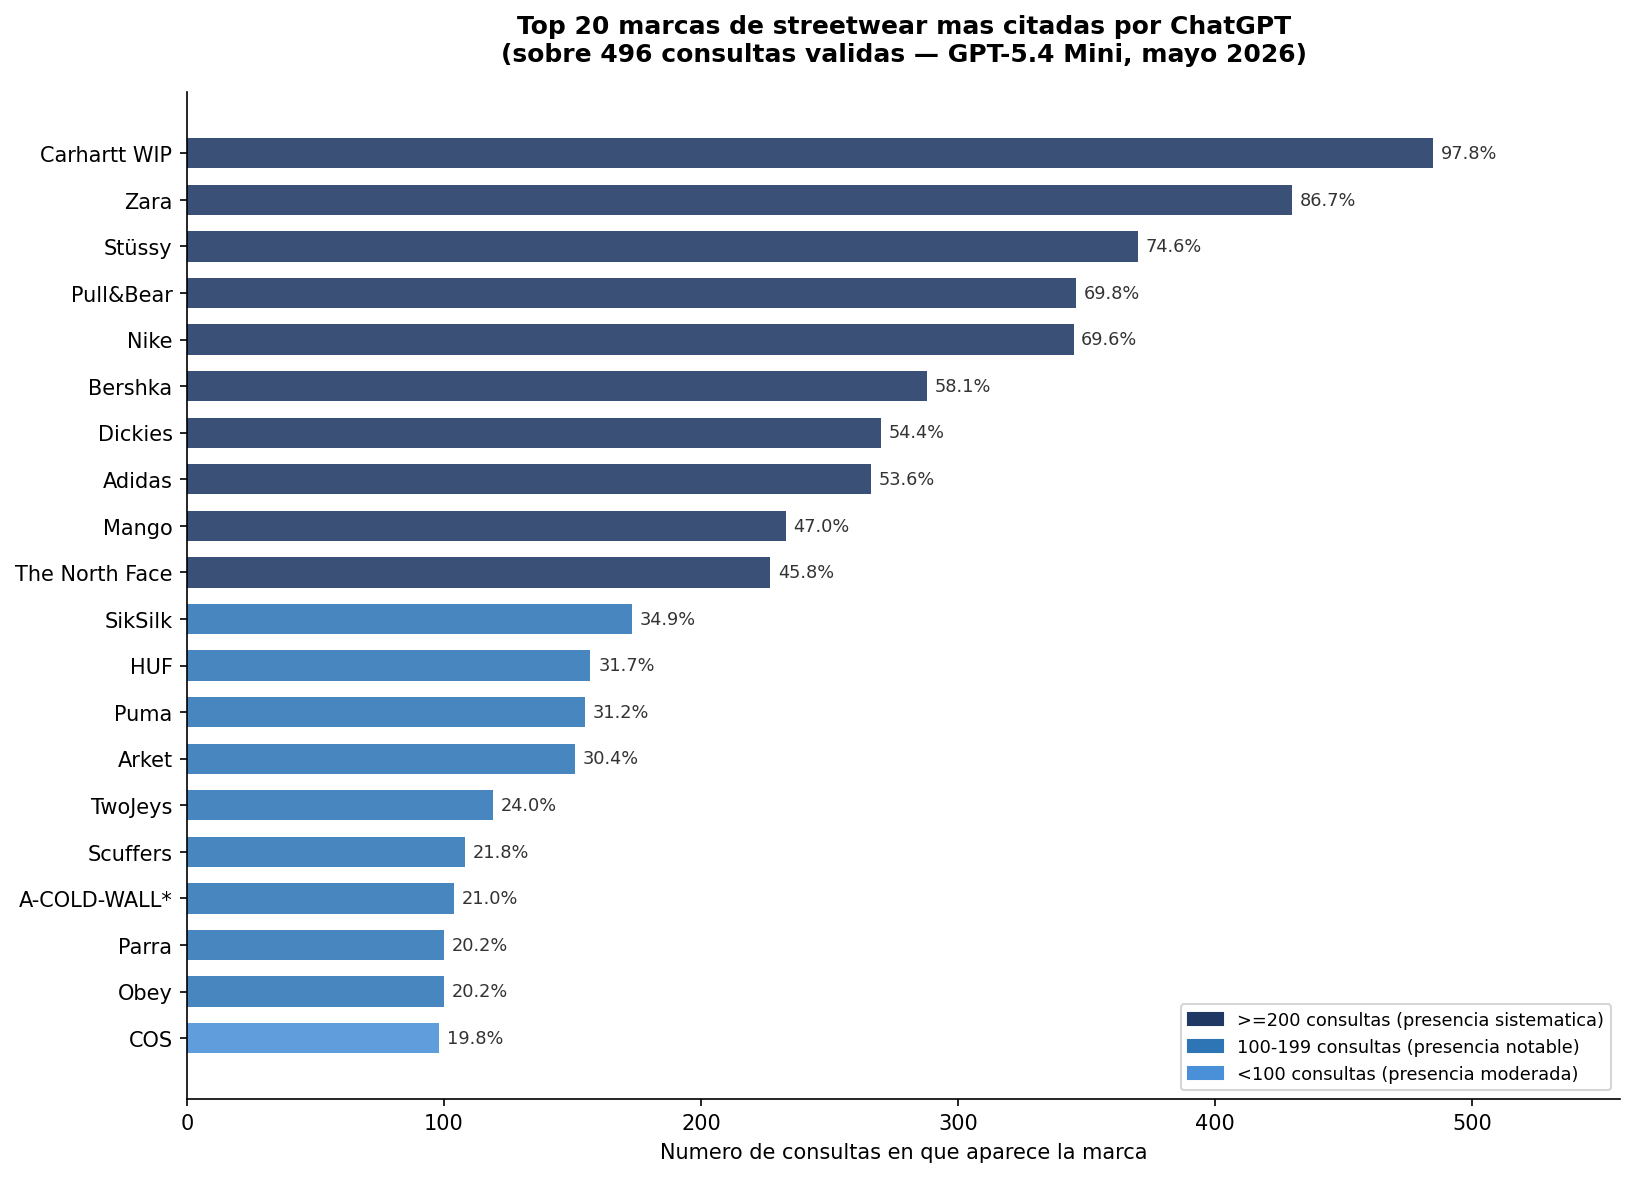

✓ G2_conocidas_vs_emergentes.png


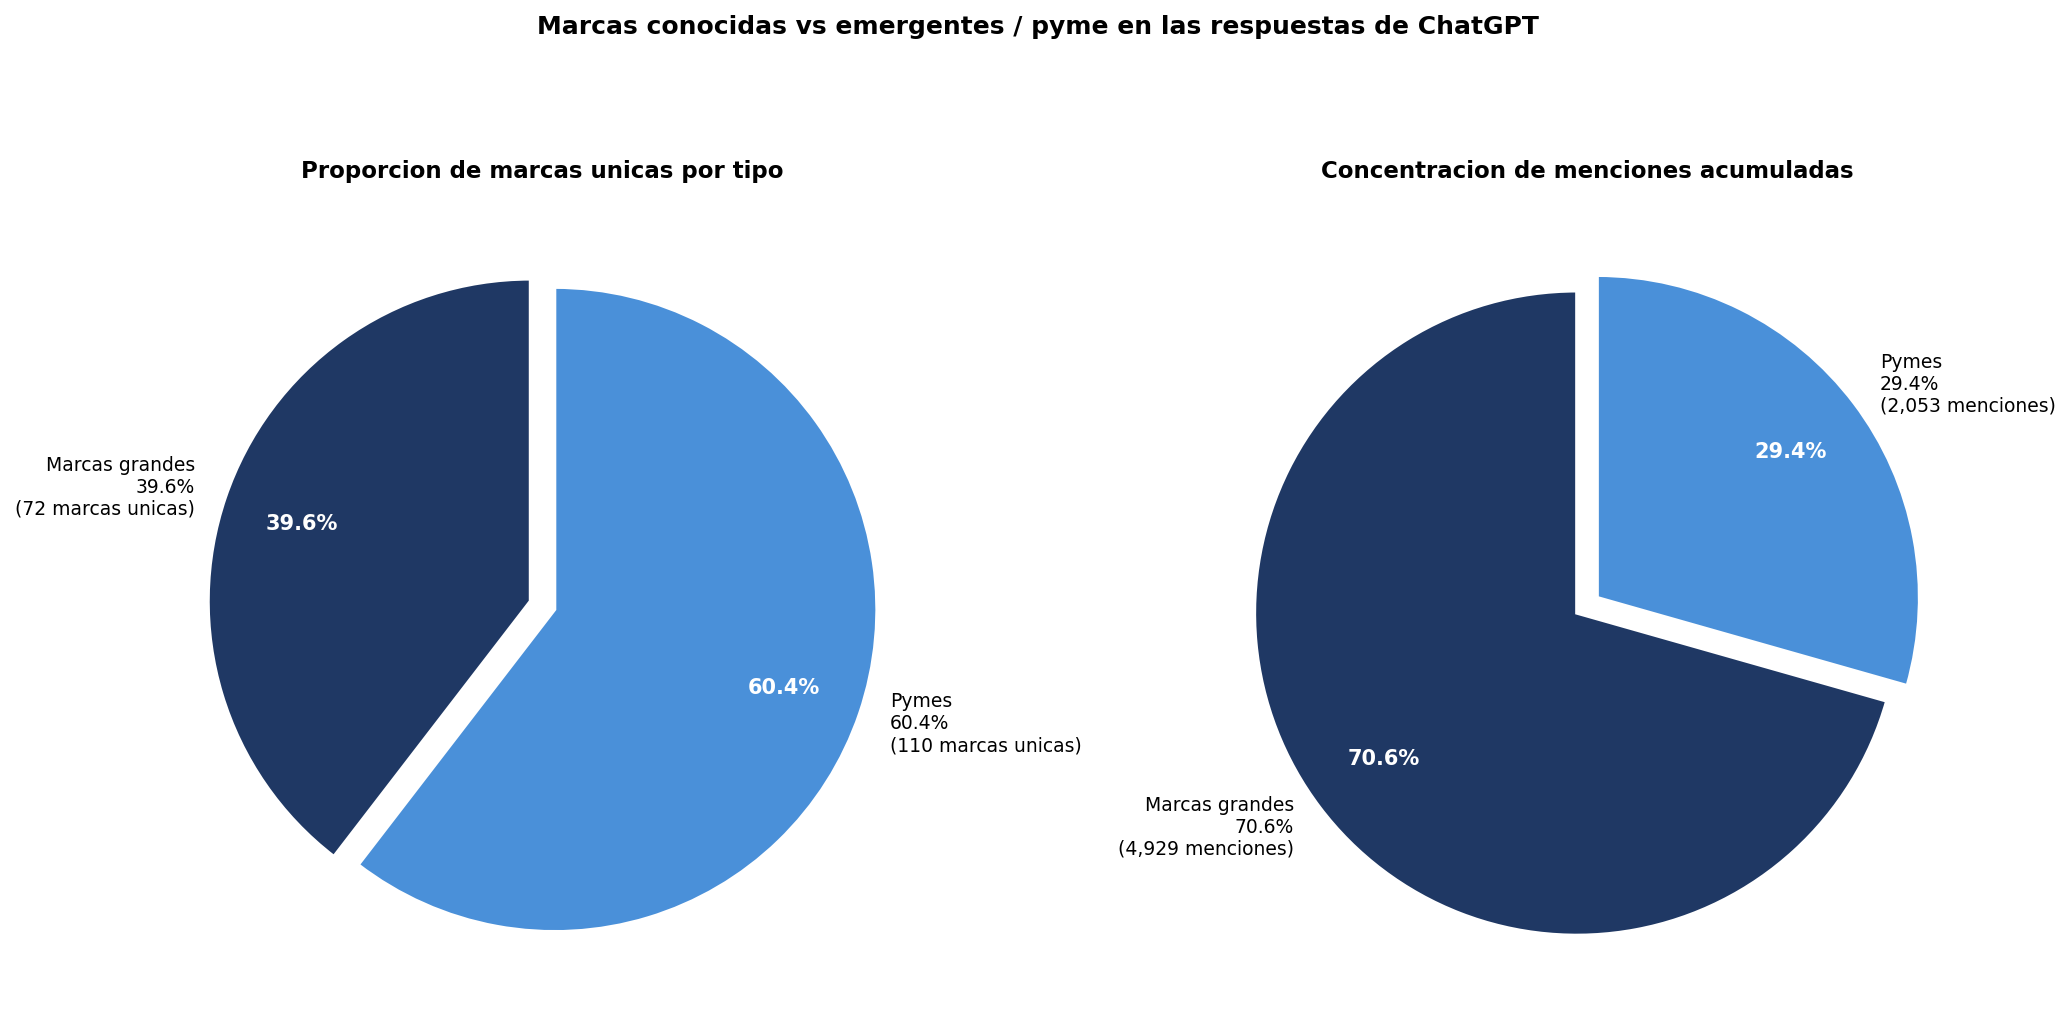

✓ G3_tipos_ecommerce.png


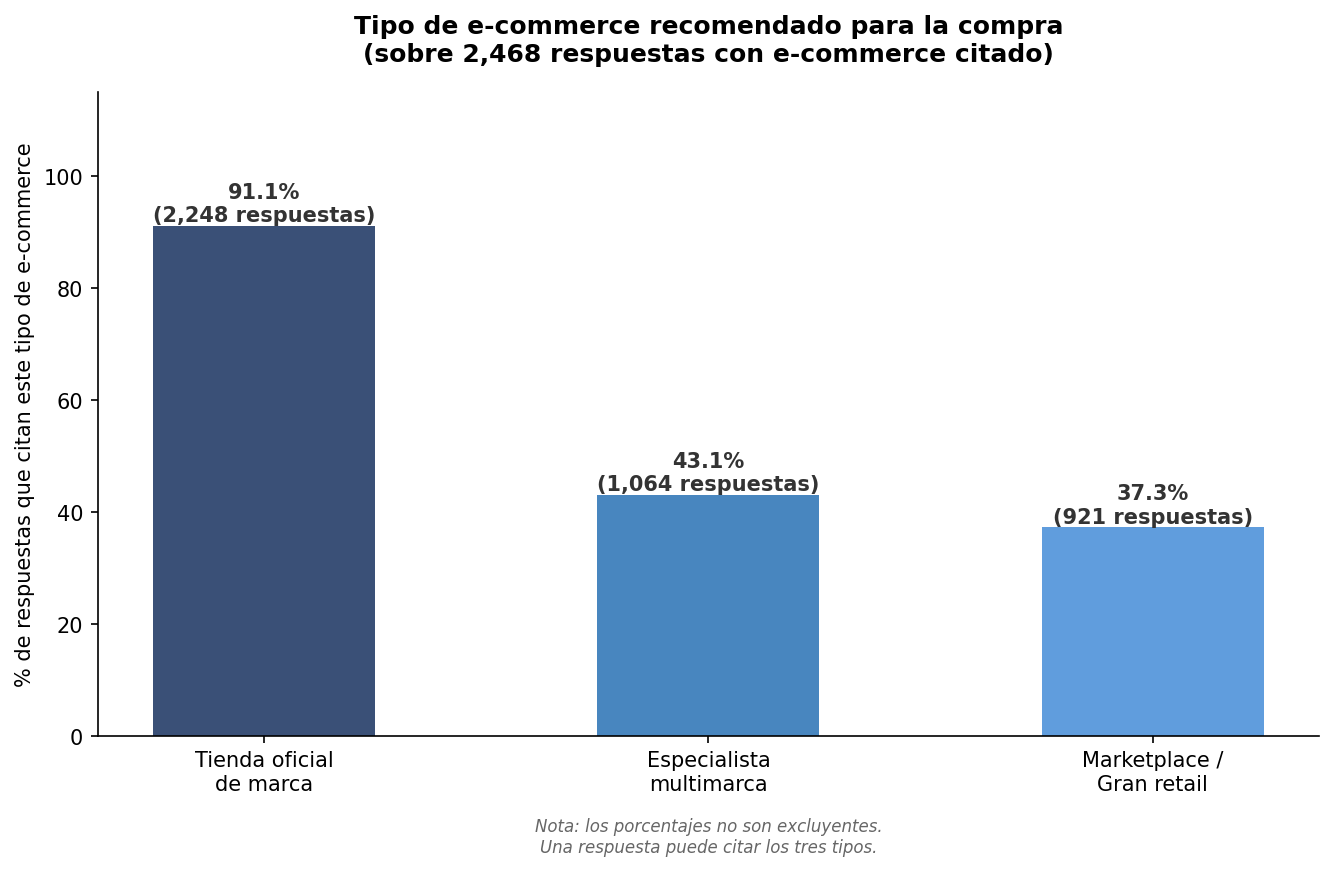


RESUMEN
Top 5: ['Carhartt WIP', 'Zara', 'Stüssy', 'Pull&Bear', 'Nike']
Conocidas: 72 marcas (39.6%) — 70.6% de las menciones
Emergentes: 110 marcas (60.4%) — 29.4% de las menciones
E-com oficial: 91.1% | Especialista: 43.1% | Marketplace: 37.3%

⚠ 213 marcas sin clasificar. Lista:


In [ ]:
"""
GRÁFICAS — Top 20 marcas, conocidas vs emergentes, tipos de ecommerce
Usar en Google Colab con resultados_openai_v6.csv
"""

import csv, math, os, re
from collections import Counter, defaultdict
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import Image, display
import warnings
warnings.filterwarnings('ignore')

os.makedirs('graficas', exist_ok=True)

COLOR1, COLOR2, COLOR3 = "#1F3864", "#2E75B6", "#4A90D9"
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

# ══════════════════════════════════════════════════════════
# CLASIFICACIÓN DE MARCAS
# ══════════════════════════════════════════════════════════

CONOCIDAS = {
    'A.P.C.', 'Acne Studios', 'Adidas', 'AllSaints', 'Alpha Industries',
    'Ami Paris', "Arc'teryx", 'Arket', 'Barbour', 'Bershka', 'Carhartt WIP',
    'Champion', 'Columbia', 'COS', 'C.P. Company', 'Decathlon', 'Desigual',
    'Dickies', 'Diesel', 'Ecoalf', 'El Ganso', 'Fjällräven', 'Fred Perry',
    'Haglöfs', 'H&M', 'Helly Hansen', 'Hugo', 'Jack & Jones', 'Kappa', 'Kith',
    'Lacoste', "Levi's", 'Maison Kitsuné', 'Mammut', 'Mango', 'Massimo Dutti',
    'Napapijri', 'New Balance', 'New Era', 'Nike', 'Obey', 'Palace',
    'Parajumpers', 'Parfois', 'Parfois Man', 'Parfois Men', 'Patagonia',
    'Polo Ralph Lauren', 'Project X Paris', 'Pull&Bear', 'Puma', 'Reiss',
    'Salsa Jeans', 'Salomon', 'Samsøe Samsøe', 'Sandro', 'Scalpers',
    'Selected Homme', 'Sézane', 'Sfera', 'SikSilk', 'Stone Island',
    'Stradivarius', 'Stüssy', 'The Kooples', 'The North Face', 'Tommy Hilfiger',
    'Uniqlo', 'Vans', 'Veja', 'Weekday', 'Zara'
}

EMERGENTES = {
    'A Bathing Ape', 'A-COLD-WALL*', 'AAPE by A Bathing Ape', 'Acho Studio',
    'Ader Error', 'Aime Leon Dore', 'A Kind of Guise', 'Alohas', 'Anerkjendt',
    'Armedangels', 'Arte Antwerp', 'Aries', 'AS Colour', 'Asket', 'Bask in the Sun',
    'Billionaire Boys Club', 'Blue Banana', 'Bobo Choses', 'Brain Dead',
    'Brava Fabrics', 'Brixton', 'Butter Goods', 'Cold Culture', 'Cole Buxton',
    'Colorful Standard', 'Corteiz', 'Daily Paper', 'Dedicated', 'Dime',
    'District Vision', 'Drôle de Monsieur', 'Eme Studios', 'Filling Pieces',
    'Gramicci', 'Grimey', 'Hélas', 'Hermanos Koumori', 'Herno', 'Herno Laminar',
    'Hombre Niño', 'Hoodrich', 'Houdini', 'HUF', 'Jaded London', 'Kaotiko',
    'Klättermusen', 'Klitmøller Collective', 'Kowtow', 'Kreator Club', 'Ksubi',
    'La Paz', 'Les Benjamins', 'Les Deux', 'Local Heroes', 'M+RC Noir',
    'Madriz Streetwear', 'Maharishi', 'Makia', 'Mason\'s', 'Meyba', 'Mister Tee',
    'Naked Copenhagen', 'NN07', 'NNormal', 'Noon Goons', 'No Problemo',
    'Norse Projects', 'Nude Project', 'Nudie Jeans', 'Our Legacy', 'Pangaia',
    'Parafina', 'Paria Farzaneh', 'Parlez', 'Parra', 'Patta', 'Penfield',
    'Percival', 'Pleasures', 'Polar Skate Co.', 'Pop Trading Company',
    'Propaganda', 'Pyrenex', 'Rains', 'Represent', 'Santa Cruz', 'Saturdays NYC',
    'Satisfy', 'Saye', 'Schott NYC', 'Scuffers', 'Séfr', 'Sepiia', 'Stan Ray',
    'Stanley', 'Stanley/Stella', 'Suitsupply', 'The Hundreds', 'The New Originals',
    'The New Society', 'The Quiet Life', 'The Ragged Priest', 'Thinking Mu',
    'Thrasher', 'TwoJeys', 'Unfeigned', 'Volcom', 'Wasted Paris', 'Hoff',
    'Aguacero Studio'
}

# ══════════════════════════════════════════════════════════
# CLASIFICACIÓN E-COMMERCES
# ══════════════════════════════════════════════════════════

MARKETPLACES = {
    'Zalando','ASOS','Amazon','El Corte Inglés','SSENSE','Farfetch',
    'About You','Boozt','Sarenza','Deporvillage','Miravia','Revolve',
    'Luisaviaroma','Mr Porter','MUSINSA','Miinto','Courir',
}

ESPECIALISTAS = {
    'END. Clothing','Sivasdescalzo','SVD','Foot District',
    'BSTN','Snipes','Blue Tomato','Slam Jam','Footshop','Skatedeluxe',
    'SkatePro','Caliroots','JD Sports','Foot Locker',
    '24Segons','Bodega','Hypebeast','Asphaltgold','No42 Barcelona',
    'Size?','Kicks Crew','Kicks Lounge','Kicks Lab','Kronjop',
    'Slam City Skates','Bergfreunde','Barrabes',
    'Tradeinn','FRESHKICKS','Titol',
}

EXCLUIR_ECOM = {
    'Zalando','ASOS','Amazon','El Corte Inglés','SSENSE','Farfetch',
    'About You','Boozt','Sarenza','Deporvillage','Miravia','Revolve',
    'Mr Porter','MUSINSA','Miinto','Courir',
    'END. Clothing','Sivasdescalzo','SVD','Foot District',
    'BSTN','Snipes','Blue Tomato','Slam Jam','Footshop','Skatedeluxe',
    'SkatePro','Caliroots','JD Sports','Foot Locker',
    '24Segons','Bodega','Hypebeast','Asphaltgold','No42 Barcelona',
    'Size?','Kicks Crew','Kicks Lounge','Kicks Lab','Kronjop',
    'Slam City Skates','Bergfreunde','Barrabes','Tradeinn','FRESHKICKS',
    'Titol','Amazon Fashion','Amazon Moda',
}

FRASES = [
    'tienda','web oficial','webs oficiales','tiendas','retailers',
    'sites como','hoodies','none','skate shop','distribuidores',
    'tiendas multimarca','tiendas oficiales','tiendas online',
    'tiendas skate','tiendas de','retailer','marcas emergentes',
    'pantalones de marca','carhartt wip es','stüssy en',
    'arc\'teryx en','houdini en','huf retailers',
    'maga skate','skate pro','kicksmaniac','xtreme skates',
    'corner street','selecta store','slam city',
]

def es_frase(m):
    lows = m.lower()
    for f in FRASES:
        if lows.startswith(f): return True
    if ' y ' in m and len(m) > 25: return True
    if m.count(',') >= 2: return True
    return False

def tipo_ecom(nombre):
    if nombre in MARKETPLACES: return 'marketplace'
    if nombre in ESPECIALISTAS: return 'especialista'
    return 'oficial'

# ══════════════════════════════════════════════════════════
# LEER CSV
# ══════════════════════════════════════════════════════════

filas = []
with open('resultados_openai_revisado.csv', encoding='utf-8') as f:
    for row in csv.DictReader(f):
        if not row.get('ERROR','').strip():
            filas.append(row)

consultas_unicas = list(set(r['ID_CONSULTA'] for r in filas))
n_consultas = len(consultas_unicas)
print(f"✓ Respuestas válidas: {len(filas)} | Consultas: {n_consultas}")

# ══════════════════════════════════════════════════════════
# MARCAS COMBINADAS (sin retailers/marketplaces)
# ══════════════════════════════════════════════════════════

marcas_por_consulta = defaultdict(set)
for row in filas:
    cid = row['ID_CONSULTA']
    for campo in ['MARCAS_CITADAS','ECOMMERCES_CITADOS']:
        for m in row.get(campo,'').split(' | '):
            m = m.strip()
            if not m or len(m) < 3: continue
            if m in EXCLUIR_ECOM: continue
            if es_frase(m): continue
            marcas_por_consulta[cid].add(m)

marcas_count = Counter()
for marcas in marcas_por_consulta.values():
    for m in marcas:
        marcas_count[m] += 1

todas_sorted = sorted(marcas_count.items(), key=lambda x:x[1], reverse=True)
print(f"✓ Marcas únicas (sin retailers): {len(todas_sorted)}")

# ══════════════════════════════════════════════════════════
# CLASIFICACIÓN CONOCIDAS vs EMERGENTES
# ══════════════════════════════════════════════════════════

n_marc_con = n_marc_eme = 0
n_cons_con = n_cons_eme = 0

for marca, n in todas_sorted:
    if marca in CONOCIDAS:
        n_marc_con += 1
        n_cons_con += n
    elif marca in EMERGENTES:
        n_marc_eme += 1
        n_cons_eme += n

total_class = n_marc_con + n_marc_eme or 1
total_cons = n_cons_con + n_cons_eme or 1
pct_mc = round(n_marc_con/total_class*100,1)
pct_me = round(n_marc_eme/total_class*100,1)
pct_cc = round(n_cons_con/total_cons*100,1)
pct_ce = round(n_cons_eme/total_cons*100,1)
sin_class = sum(1 for m,_ in todas_sorted if m not in CONOCIDAS and m not in EMERGENTES)

print(f"✓ Conocidas: {n_marc_con} marcas | Emergentes: {n_marc_eme} | Sin clasificar: {sin_class}")

# ══════════════════════════════════════════════════════════
# E-COMMERCES POR TIPO
# ══════════════════════════════════════════════════════════

oficial_r = marketplace_r = especialista_r = total_r = 0
ecom_por_tipo = defaultdict(Counter)

for row in filas:
    ecom_list = []
    for e in row.get('ECOMMERCES_CITADOS','').split(' | '):
        e = e.strip()
        if e and len(e) > 2 and not es_frase(e):
            ecom_list.append(e)
    if not ecom_list: continue
    total_r += 1
    seen = set()
    tipos = set()
    for e in ecom_list:
        t = tipo_ecom(e)
        tipos.add(t)
        if e not in seen:
            seen.add(e)
            ecom_por_tipo[t][e] += 1
    if 'oficial' in tipos: oficial_r += 1
    if 'marketplace' in tipos: marketplace_r += 1
    if 'especialista' in tipos: especialista_r += 1

pct_of = round(oficial_r/total_r*100,1) if total_r else 0
pct_mk = round(marketplace_r/total_r*100,1) if total_r else 0
pct_es = round(especialista_r/total_r*100,1) if total_r else 0

print(f"✓ E-com: oficial {pct_of}% | especialista {pct_es}% | marketplace {pct_mk}%")

# ══════════════════════════════════════════════════════════
# G1 — TOP 20 MARCAS (barras horizontal)
# ══════════════════════════════════════════════════════════

top20 = todas_sorted[:20]
noms = [m for m,_ in reversed(top20)]
vals = [n for _,n in reversed(top20)]
pcts = [round(n/n_consultas*100,1) for _,n in reversed(top20)]
cols = [COLOR1 if v>=200 else COLOR2 if v>=100 else COLOR3 for v in vals]

fig, ax = plt.subplots(figsize=(11,8))
bars = ax.barh(noms, vals, color=cols, alpha=0.88, height=0.65)
for bar, pct in zip(bars, pcts):
    ax.text(bar.get_width()+3, bar.get_y()+bar.get_height()/2,
            f'{pct}%', va='center', fontsize=8.5, color='#333')
ax.set_xlabel('Numero de consultas en que aparece la marca', fontsize=10)
ax.set_title('Top 20 marcas de streetwear mas citadas por ChatGPT\n(sobre 496 consultas validas — GPT-5.4 Mini, mayo 2026)',
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlim(0, max(vals)*1.15)
leyenda = [
    mpatches.Patch(color=COLOR1, label='>=200 consultas (presencia sistematica)'),
    mpatches.Patch(color=COLOR2, label='100-199 consultas (presencia notable)'),
    mpatches.Patch(color=COLOR3, label='<100 consultas (presencia moderada)'),
]
ax.legend(handles=leyenda, fontsize=8.5, loc='lower right')
plt.tight_layout()
plt.savefig('graficas/G1_top20_marcas.png', dpi=150, bbox_inches='tight')
plt.close()
print("✓ G1_top20_marcas.png")
display(Image('graficas/G1_top20_marcas.png'))

# ══════════════════════════════════════════════════════════
# G2 — MARCAS CONOCIDAS VS EMERGENTES (doble tarta)
# ══════════════════════════════════════════════════════════

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,7))

for ax, sizes, labels, titulo in [
    (ax1,
     [n_marc_con, n_marc_eme],
     [f'Marcas grandes\n{pct_mc}%\n({n_marc_con} marcas unicas)',
      f'Pymes\n{pct_me}%\n({n_marc_eme} marcas unicas)'],
     'Proporcion de marcas unicas por tipo'),
    (ax2,
     [n_cons_con, n_cons_eme],
     [f'Marcas grandes\n{pct_cc}%\n({n_cons_con:,} menciones)',
      f'Pymes\n{pct_ce}%\n({n_cons_eme:,} menciones)'],
     'Concentracion de menciones acumuladas'),
]:
    wedges, texts, autotexts = ax.pie(
        sizes, labels=labels, colors=[COLOR1, COLOR3],
        explode=(0.04,0.04), startangle=90,
        textprops={'fontsize':9},
        wedgeprops={'linewidth':1.5,'edgecolor':'white'},
        autopct='%1.1f%%', pctdistance=0.75
    )
    for at in autotexts: at.set_fontsize(10); at.set_fontweight('bold'); at.set_color('white')
    ax.set_title(titulo, fontsize=11, fontweight='bold', pad=12)

plt.suptitle('Marcas conocidas vs emergentes / pyme en las respuestas de ChatGPT\n',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('graficas/G2_conocidas_vs_emergentes.png', dpi=150, bbox_inches='tight')
plt.close()
print("✓ G2_conocidas_vs_emergentes.png")
display(Image('graficas/G2_conocidas_vs_emergentes.png'))

# ══════════════════════════════════════════════════════════
# G3 — TIPOS DE E-COMMERCE (barras)
# ══════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(9,6))
t_labels = ['Tienda oficial\nde marca', 'Especialista\nmultimarca', 'Marketplace /\nGran retail']
t_vals   = [pct_of, pct_es, pct_mk]
t_ns     = [oficial_r, especialista_r, marketplace_r]
t_cols   = [COLOR1, COLOR2, COLOR3]

bars = ax.bar(t_labels, t_vals, color=t_cols, alpha=0.88, width=0.5)
for bar, pct, n in zip(bars, t_vals, t_ns):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
            f'{pct}%\n({n:,} respuestas)',
            ha='center', fontsize=10, fontweight='bold', color='#333')

ax.set_ylabel('% de respuestas que citan este tipo de e-commerce', fontsize=10)
ax.set_ylim(0, 115)
ax.set_title(f'Tipo de e-commerce recomendado para la compra\n(sobre {total_r:,} respuestas con e-commerce citado)',
             fontsize=12, fontweight='bold', pad=15)

nota = ('Nota: los porcentajes no son excluyentes.\n'
        'Una respuesta puede citar los tres tipos.')
ax.text(0.5, -0.18, nota, transform=ax.transAxes,
        ha='center', fontsize=8, color='#666', style='italic')

plt.tight_layout()
plt.savefig('graficas/G3_tipos_ecommerce.png', dpi=150, bbox_inches='tight')
plt.close()
print("✓ G3_tipos_ecommerce.png")
display(Image('graficas/G3_tipos_ecommerce.png'))

# ══════════════════════════════════════════════════════════
# RESUMEN
# ══════════════════════════════════════════════════════════
print("\n" + "="*50)
print("RESUMEN")
print("="*50)
print(f"Top 5: {[m for m,_ in todas_sorted[:5]]}")
print(f"Conocidas: {n_marc_con} marcas ({pct_mc}%) — {pct_cc}% de las menciones")
print(f"Emergentes: {n_marc_eme} marcas ({pct_me}%) — {pct_ce}% de las menciones")
print(f"E-com oficial: {pct_of}% | Especialista: {pct_es}% | Marketplace: {pct_mk}%")
if sin_class > 0:
    print(f"\n⚠ {sin_class} marcas sin clasificar. Lista:")
    for m,n in todas_sorted:
        if m not in CONOCIDAS and m not in EMERGENTES and n >= 3:
            print(f"  {m}: {n}")

# ══════════════════════════════════════════════════════════
# DESCARGA (ejecutar en celda separada)
# ══════════════════════════════════════════════════════════
# from google.colab import files
# files.download('graficas/G1_top20_marcas.png')
# files.download('graficas/G2_conocidas_vs_emergentes.png')
# files.download('graficas/G3_tipos_ecommerce.png')

✓ Respuestas válidas: 2474 | Consultas: 496
✓ Marcas únicas (sin retailers): 742
✓ Conocidas: 62 marcas | Emergentes: 94 | Sin clasificar: 586
✓ E-com: oficial 93.7% | especialista 43.9% | marketplace 27.9%
✓ G1_top20_marcas.png


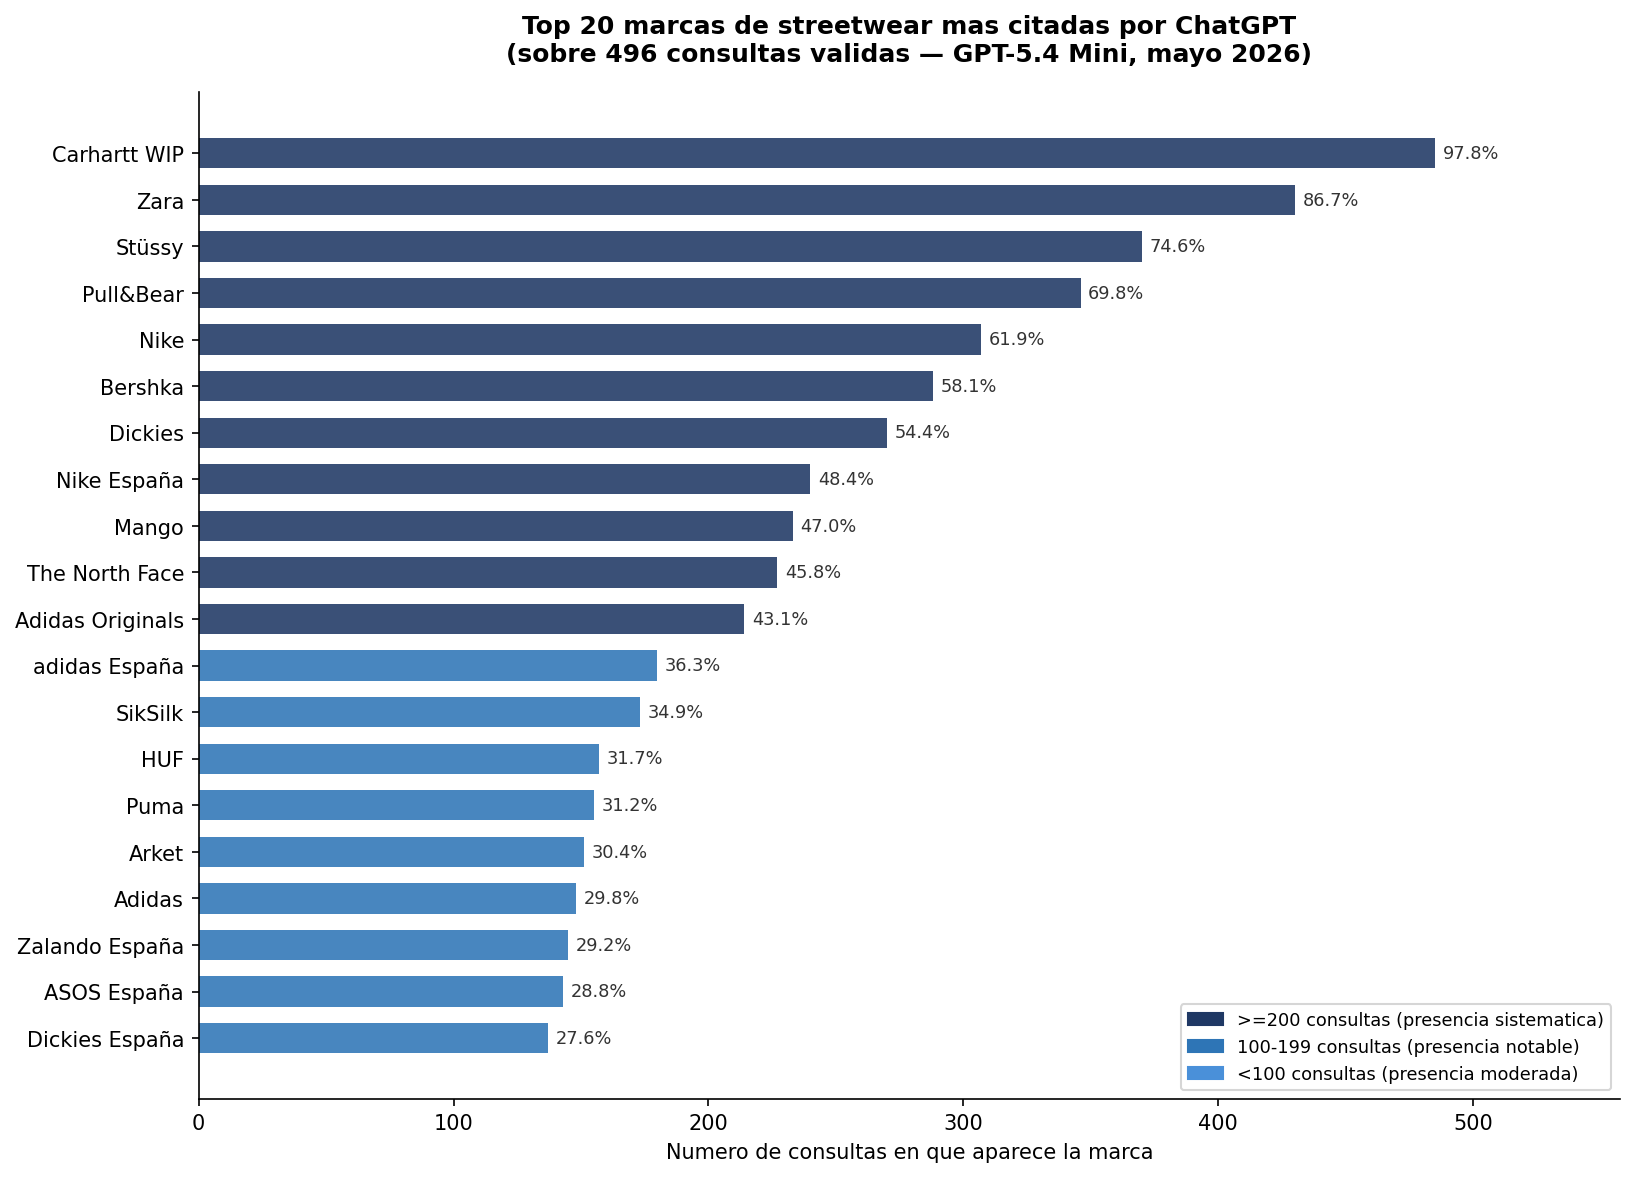

✓ G2_conocidas_vs_emergentes.png


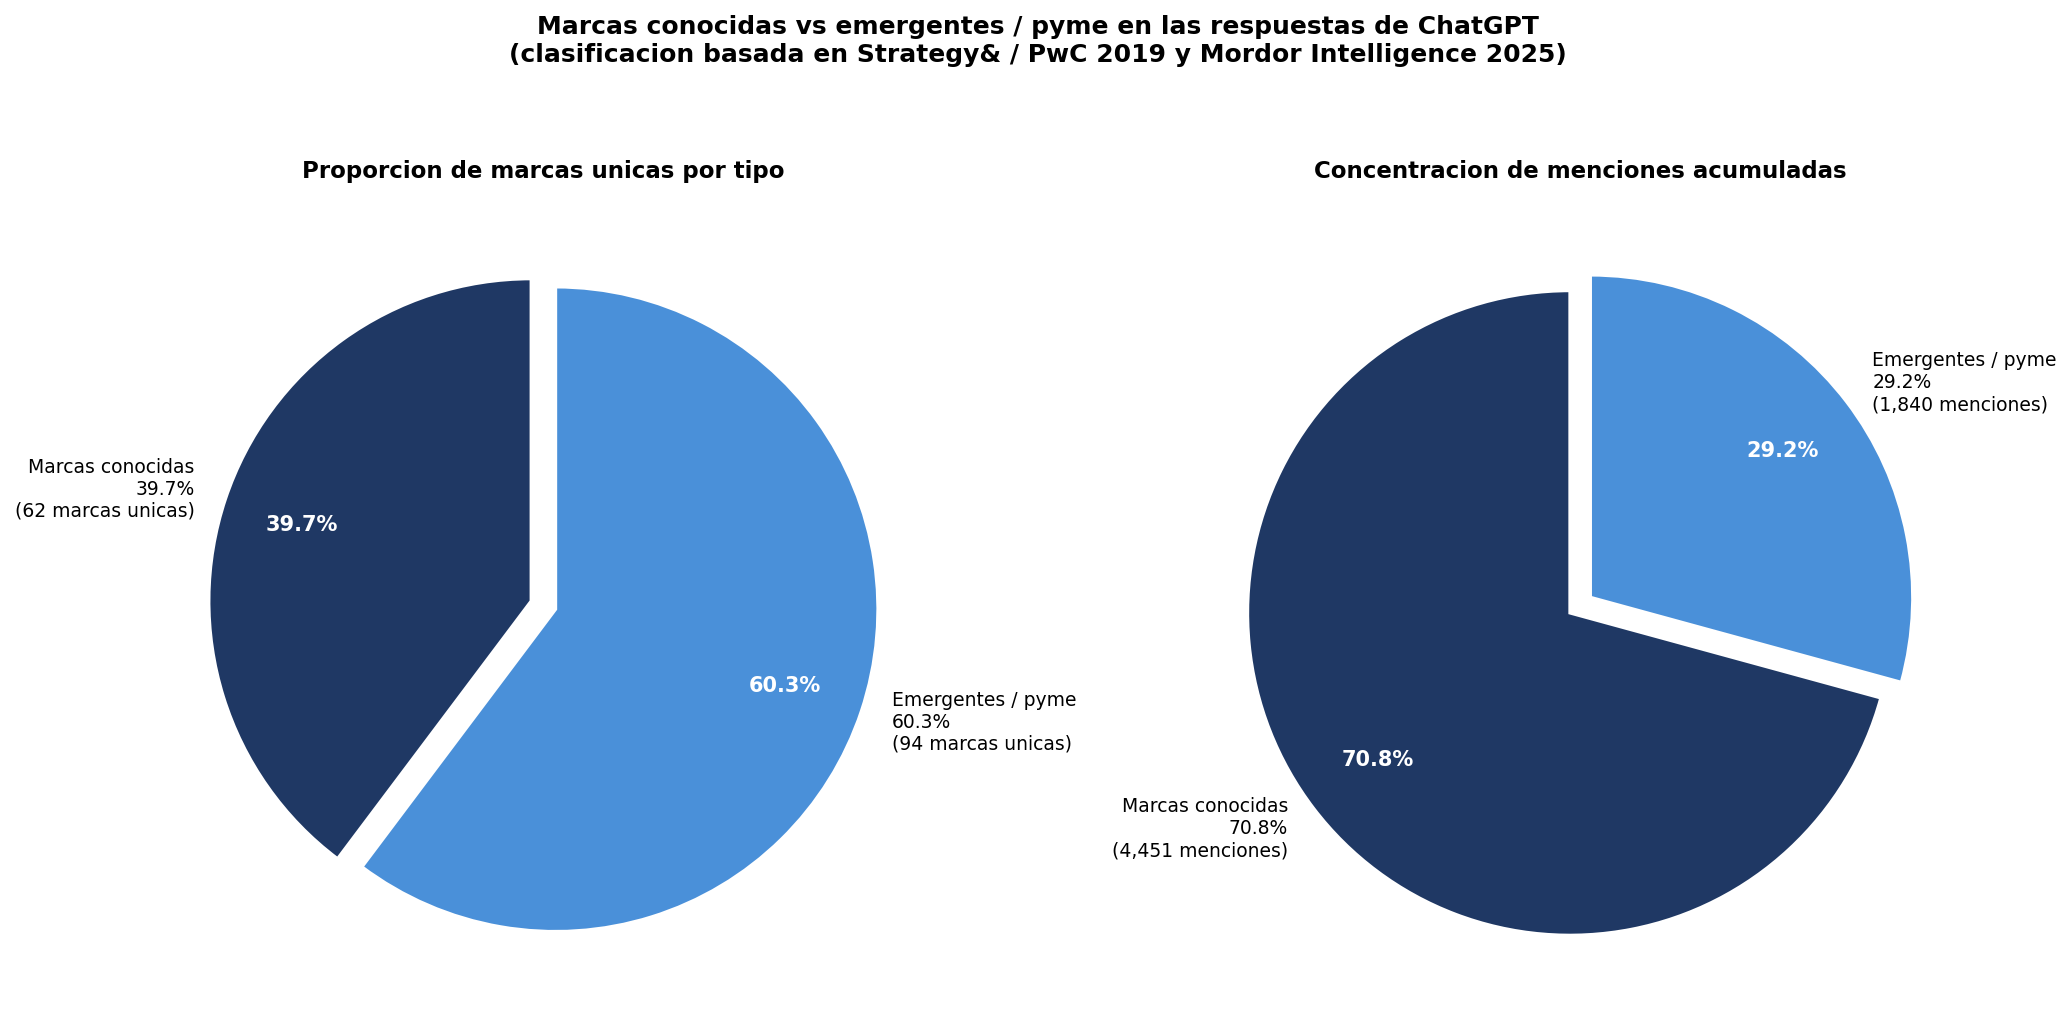

✓ G3_tipos_ecommerce.png


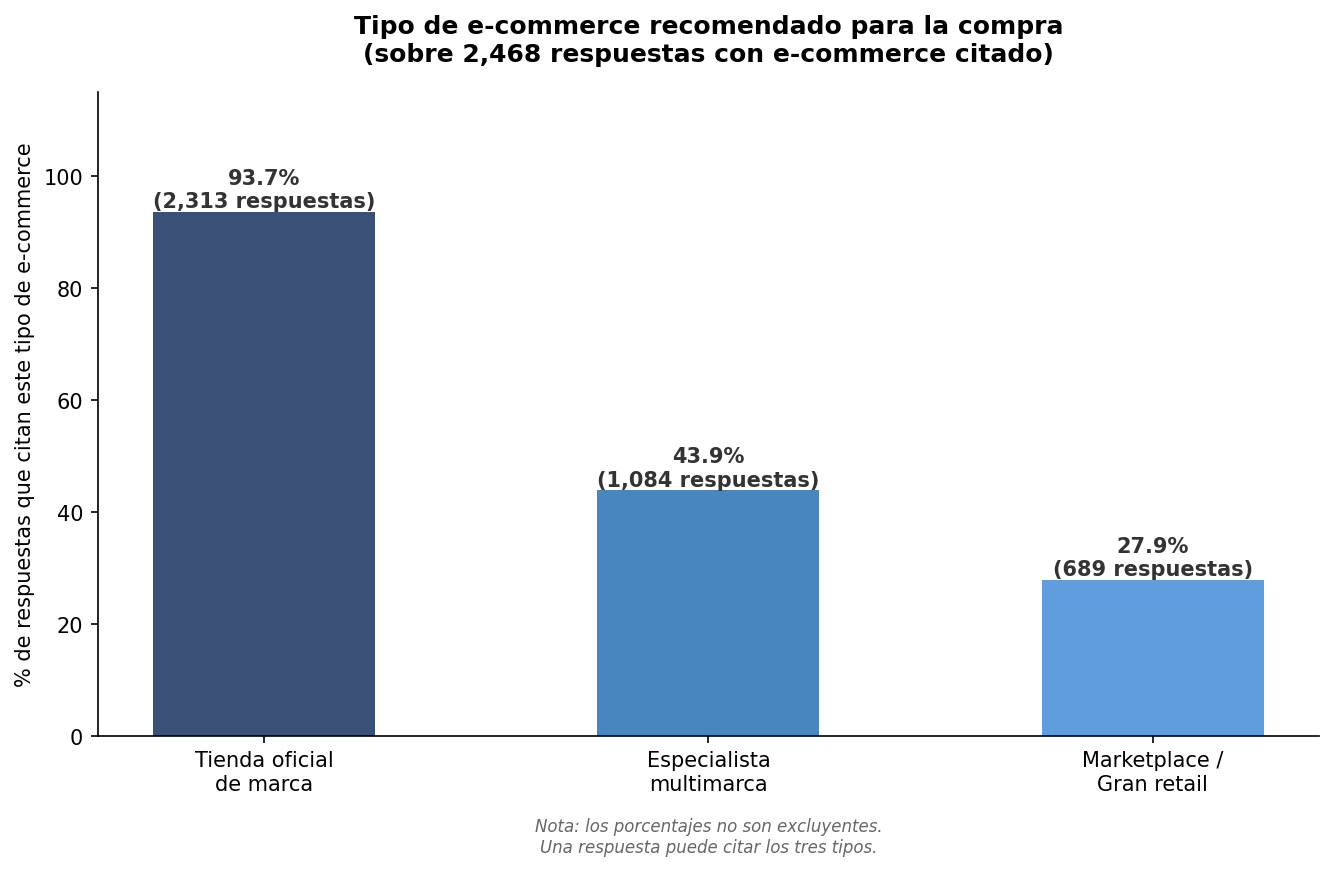


RESUMEN
Top 5: ['Carhartt WIP', 'Zara', 'Stüssy', 'Pull&Bear', 'Nike']
Conocidas: 62 marcas (39.7%) — 70.8% de las menciones
Emergentes: 94 marcas (60.3%) — 29.2% de las menciones
E-com oficial: 93.7% | Especialista: 43.9% | Marketplace: 27.9%

⚠ 586 marcas sin clasificar. Lista:
  Nike España: 240
  The North Face: 227
  Adidas Originals: 214
  adidas España: 180
  Zalando España: 145
  ASOS España: 143
  Dickies España: 137
  Carhartt WIP Store España: 121
  Footdistrict: 115
  Nike ACG: 105
  The North Face España: 102
  Zara España: 80
  Mango Man: 74
  Foot Locker España: 71
  adidas.es: 69
  adidas: 68
  Nike.com/es: 65
  JD Sports España: 61
  Carhartt WIP Store: 48
  Levi's España: 45
  Carhartt WIP Spain: 42
  zara.com/es: 41
  Pull&Bear España: 40
  Arket España: 40
  COS España: 36
  carhartt-wip.com/es: 36
  pullandbear.com/es: 35
  Stüssy EU: 35
  Uniqlo España: 33
  Adidas España: 32
  Patagonia España: 29
  New Balance España: 27
  Bershka España: 26
  Puma España: 26
 

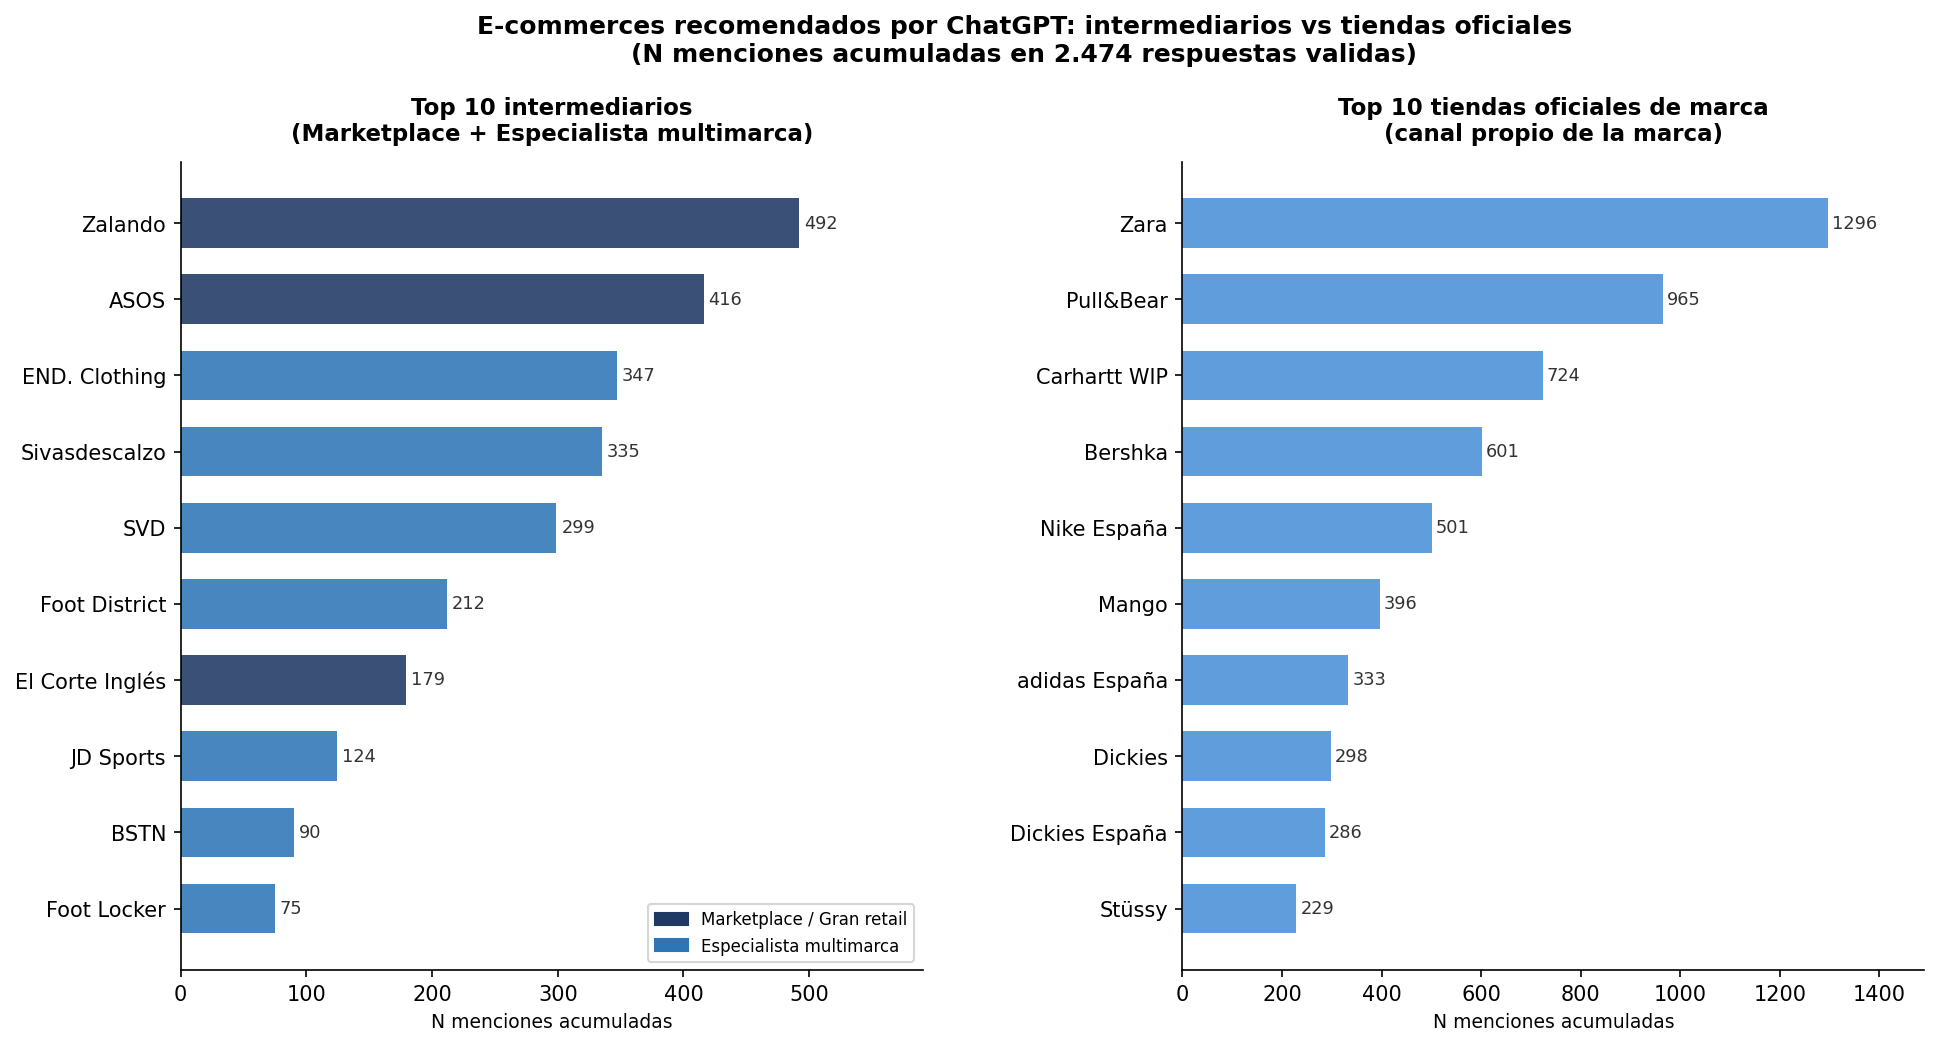

In [1]:
"""
Top 20 marcas, conocidas vs emergentes, tipos de ecommerce

"""

import csv, math, os, re
from collections import Counter, defaultdict
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import Image, display
import warnings
warnings.filterwarnings('ignore')

os.makedirs('graficas', exist_ok=True)

COLOR1, COLOR2, COLOR3 = "#1F3864", "#2E75B6", "#4A90D9"
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

# ══════════════════════════════════════════════════════════
# CLASIFICACIÓN DE MARCAS
# ══════════════════════════════════════════════════════════

CONOCIDAS = {
    'Acne Studios','Adidas','AllSaints','Alpha Industries','Ami Paris',
    "A.P.C.","Arc'teryx",'Arket','Barbour','Bershka','Carhartt WIP',
    'Champion','Columbia','COS','C.P. Company','Desigual','Dickies',
    'Ecoalf','El Ganso','Fjällräven','Fred Perry','Haglöfs','H&M',
    'Helly Hansen','Hugo','Jack & Jones','Kith','Lacoste',
    "Levi's",'Maison Kitsuné','Mammut','Mango','Massimo Dutti',
    'Napapijri','New Balance','New Era','Nike','Obey','Palace',
    'Parajumpers','Parfois','Patagonia','Polo Ralph Lauren','Pull&Bear',
    'Puma','Reiss','Salomon','Samsøe Samsøe','Sandro','Scalpers',
    'Selected Homme','Sézane','SikSilk','Stone Island','Stradivarius',
    'Stüssy','Tommy Hilfiger','Uniqlo','Vans','Veja','Weekday','Zara',
}

EMERGENTES = {
    'A-COLD-WALL*','Acho Studio','Ader Error','Aime Leon Dore',
    'A Kind of Guise','Alohas','Anerkjendt','Armedangels','Arte Antwerp',
    'Aries','Asket','Bask in the Sun','Billionaire Boys Club','Blue Banana',
    'Bobo Choses','Brain Dead','Brava Fabrics','Brixton','Butter Goods',
    'Cold Culture','Cole Buxton','Colorful Standard','Corteiz','Daily Paper',
    'Dedicated','Dime','District Vision','Drôle de Monsieur','Eme Studios',
    'Filling Pieces','Gramicci','Grimey','Hélas','Hermanos Koumori','Herno',
    'Hombre Niño','Hoodrich','HUF','Kaotiko','Klitmøller Collective','Kowtow',
    'Kreator Club','Ksubi','La Paz','Les Benjamins','Les Deux','Local Heroes',
    'M+RC Noir','Madriz Streetwear','Maharishi','Makia','Meyba','Mister Tee',
    'NN07','NNormal','Noon Goons','No Problemo','Norse Projects','Nude Project',
    'Nudie Jeans','Our Legacy','Pangaia','Parafina','Paria Farzaneh','Parlez',
    'Parra','Patta','Penfield','Percival','Pleasures','Polar Skate Co.',
    'Pop Trading Company','Pyrenex','Rains','Represent','Santa Cruz',
    'Saturdays NYC','Satisfy','Saye','Schott NYC','Séfr','Sepiia','Stan Ray',
    'Suitsupply','The Hundreds','The New Originals','The Quiet Life',
    'Thinking Mu','TwoJeys','Unfeigned','Volcom','Wasted Paris',
    'Hoff','Aguacero Studio','Parafina',
}

# ══════════════════════════════════════════════════════════
# CLASIFICACIÓN E-COMMERCES
# ══════════════════════════════════════════════════════════

MARKETPLACES = {
    'Zalando','ASOS','Amazon','El Corte Inglés','SSENSE','Farfetch',
    'About You','Boozt','Sarenza','Deporvillage','Miravia','Revolve',
    'Luisaviaroma','Mr Porter','MUSINSA','Miinto','Courir',
}

ESPECIALISTAS = {
    'END. Clothing','Sivasdescalzo','SVD','Foot District','Scuffers',
    'BSTN','Snipes','Blue Tomato','Slam Jam','Footshop','Skatedeluxe',
    'SkatePro','Caliroots','JD Sports','Foot Locker',
    '24Segons','Bodega','Hypebeast','Asphaltgold','No42 Barcelona',
    'Size?','Kicks Crew','Kicks Lounge','Kicks Lab','Kronjop',
    'Luisaviaroma','Slam City Skates','Bergfreunde','Barrabes',
    'Tradeinn','FRESHKICKS','Titol',
}

EXCLUIR_ECOM = {
    'Zalando','ASOS','Amazon','El Corte Inglés','SSENSE','Farfetch',
    'About You','Boozt','Sarenza','Deporvillage','Miravia','Revolve',
    'Mr Porter','MUSINSA','Miinto','Courir',
    'END. Clothing','Sivasdescalzo','SVD','Foot District','Scuffers',
    'BSTN','Snipes','Blue Tomato','Slam Jam','Footshop','Skatedeluxe',
    'SkatePro','Caliroots','JD Sports','Foot Locker',
    '24Segons','Bodega','Hypebeast','Asphaltgold','No42 Barcelona',
    'Size?','Kicks Crew','Kicks Lounge','Kicks Lab','Kronjop',
    'Slam City Skates','Bergfreunde','Barrabes','Tradeinn','FRESHKICKS',
    'Titol','Amazon Fashion','Amazon Moda',
}

FRASES = [
    'tienda','web oficial','webs oficiales','tiendas','retailers',
    'sites como','hoodies','none','skate shop','distribuidores',
    'tiendas multimarca','tiendas oficiales','tiendas online',
    'tiendas skate','tiendas de','retailer','marcas emergentes',
    'pantalones de marca','carhartt wip es','stüssy en',
    'arc\'teryx en','houdini en','huf retailers',
    'maga skate','skate pro','kicksmaniac','xtreme skates',
    'corner street','selecta store','slam city',
]

def es_frase(m):
    lows = m.lower()
    for f in FRASES:
        if lows.startswith(f): return True
    if ' y ' in m and len(m) > 25: return True
    if m.count(',') >= 2: return True
    return False

def tipo_ecom(nombre):
    if nombre in MARKETPLACES: return 'marketplace'
    if nombre in ESPECIALISTAS: return 'especialista'
    return 'oficial'

# ══════════════════════════════════════════════════════════
# LEER CSV
# ══════════════════════════════════════════════════════════

filas = []
with open('resultados_openai_clean.csv', encoding='utf-8') as f:
    for row in csv.DictReader(f):
        if not row.get('ERROR','').strip():
            filas.append(row)

consultas_unicas = list(set(r['ID_CONSULTA'] for r in filas))
n_consultas = len(consultas_unicas)
print(f"✓ Respuestas válidas: {len(filas)} | Consultas: {n_consultas}")

# ══════════════════════════════════════════════════════════
# MARCAS COMBINADAS (sin retailers/marketplaces)
# ══════════════════════════════════════════════════════════

marcas_por_consulta = defaultdict(set)
for row in filas:
    cid = row['ID_CONSULTA']
    for campo in ['MARCAS_CITADAS','ECOMMERCES_CITADOS']:
        for m in row.get(campo,'').split(' | '):
            m = m.strip()
            if not m or len(m) < 3: continue
            if m in EXCLUIR_ECOM: continue
            if es_frase(m): continue
            marcas_por_consulta[cid].add(m)

marcas_count = Counter()
for marcas in marcas_por_consulta.values():
    for m in marcas:
        marcas_count[m] += 1

todas_sorted = sorted(marcas_count.items(), key=lambda x:x[1], reverse=True)
print(f"✓ Marcas únicas (sin retailers): {len(todas_sorted)}")

# ══════════════════════════════════════════════════════════
# CLASIFICACIÓN CONOCIDAS vs EMERGENTES
# ══════════════════════════════════════════════════════════

n_marc_con = n_marc_eme = 0
n_cons_con = n_cons_eme = 0

for marca, n in todas_sorted:
    if marca in CONOCIDAS:
        n_marc_con += 1
        n_cons_con += n
    elif marca in EMERGENTES:
        n_marc_eme += 1
        n_cons_eme += n

total_class = n_marc_con + n_marc_eme or 1
total_cons = n_cons_con + n_cons_eme or 1
pct_mc = round(n_marc_con/total_class*100,1)
pct_me = round(n_marc_eme/total_class*100,1)
pct_cc = round(n_cons_con/total_cons*100,1)
pct_ce = round(n_cons_eme/total_cons*100,1)
sin_class = sum(1 for m,_ in todas_sorted if m not in CONOCIDAS and m not in EMERGENTES)

print(f"✓ Conocidas: {n_marc_con} marcas | Emergentes: {n_marc_eme} | Sin clasificar: {sin_class}")

# ══════════════════════════════════════════════════════════
# E-COMMERCES POR TIPO
# ══════════════════════════════════════════════════════════

oficial_r = marketplace_r = especialista_r = total_r = 0
ecom_por_tipo = defaultdict(Counter)

for row in filas:
    ecom_list = []
    for e in row.get('ECOMMERCES_CITADOS','').split(' | '):
        e = e.strip()
        if e and len(e) > 2 and not es_frase(e):
            ecom_list.append(e)
    if not ecom_list: continue
    total_r += 1
    seen = set()
    tipos = set()
    for e in ecom_list:
        t = tipo_ecom(e)
        tipos.add(t)
        if e not in seen:
            seen.add(e)
            ecom_por_tipo[t][e] += 1
    if 'oficial' in tipos: oficial_r += 1
    if 'marketplace' in tipos: marketplace_r += 1
    if 'especialista' in tipos: especialista_r += 1

pct_of = round(oficial_r/total_r*100,1) if total_r else 0
pct_mk = round(marketplace_r/total_r*100,1) if total_r else 0
pct_es = round(especialista_r/total_r*100,1) if total_r else 0

print(f"✓ E-com: oficial {pct_of}% | especialista {pct_es}% | marketplace {pct_mk}%")

# ══════════════════════════════════════════════════════════
# G1 — TOP 20 MARCAS (barras horizontal)
# ══════════════════════════════════════════════════════════

top20 = todas_sorted[:20]
noms = [m for m,_ in reversed(top20)]
vals = [n for _,n in reversed(top20)]
pcts = [round(n/n_consultas*100,1) for _,n in reversed(top20)]
cols = [COLOR1 if v>=200 else COLOR2 if v>=100 else COLOR3 for v in vals]

fig, ax = plt.subplots(figsize=(11,8))
bars = ax.barh(noms, vals, color=cols, alpha=0.88, height=0.65)
for bar, pct in zip(bars, pcts):
    ax.text(bar.get_width()+3, bar.get_y()+bar.get_height()/2,
            f'{pct}%', va='center', fontsize=8.5, color='#333')
ax.set_xlabel('Numero de consultas en que aparece la marca', fontsize=10)
ax.set_title('Top 20 marcas de streetwear mas citadas por ChatGPT\n(sobre 496 consultas validas — GPT-5.4 Mini, mayo 2026)',
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlim(0, max(vals)*1.15)
leyenda = [
    mpatches.Patch(color=COLOR1, label='>=200 consultas (presencia sistematica)'),
    mpatches.Patch(color=COLOR2, label='100-199 consultas (presencia notable)'),
    mpatches.Patch(color=COLOR3, label='<100 consultas (presencia moderada)'),
]
ax.legend(handles=leyenda, fontsize=8.5, loc='lower right')
plt.tight_layout()
plt.savefig('graficas/G1_top20_marcas.png', dpi=150, bbox_inches='tight')
plt.close()
print("✓ G1_top20_marcas.png")
display(Image('graficas/G1_top20_marcas.png'))

# ══════════════════════════════════════════════════════════
# G2 — MARCAS CONOCIDAS VS EMERGENTES (doble tarta)
# ══════════════════════════════════════════════════════════

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,7))

for ax, sizes, labels, titulo in [
    (ax1,
     [n_marc_con, n_marc_eme],
     [f'Marcas conocidas\n{pct_mc}%\n({n_marc_con} marcas unicas)',
      f'Emergentes / pyme\n{pct_me}%\n({n_marc_eme} marcas unicas)'],
     'Proporcion de marcas unicas por tipo'),
    (ax2,
     [n_cons_con, n_cons_eme],
     [f'Marcas conocidas\n{pct_cc}%\n({n_cons_con:,} menciones)',
      f'Emergentes / pyme\n{pct_ce}%\n({n_cons_eme:,} menciones)'],
     'Concentracion de menciones acumuladas'),
]:
    wedges, texts, autotexts = ax.pie(
        sizes, labels=labels, colors=[COLOR1, COLOR3],
        explode=(0.04,0.04), startangle=90,
        textprops={'fontsize':9},
        wedgeprops={'linewidth':1.5,'edgecolor':'white'},
        autopct='%1.1f%%', pctdistance=0.75
    )
    for at in autotexts: at.set_fontsize(10); at.set_fontweight('bold'); at.set_color('white')
    ax.set_title(titulo, fontsize=11, fontweight='bold', pad=12)

plt.suptitle('Marcas conocidas vs emergentes / pyme en las respuestas de ChatGPT\n(clasificacion basada en Strategy& / PwC 2019 y Mordor Intelligence 2025)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('graficas/G2_conocidas_vs_emergentes.png', dpi=150, bbox_inches='tight')
plt.close()
print("✓ G2_conocidas_vs_emergentes.png")
display(Image('graficas/G2_conocidas_vs_emergentes.png'))

# ══════════════════════════════════════════════════════════
# G3 — TIPOS DE E-COMMERCE (barras)
# ══════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(9,6))
t_labels = ['Tienda oficial\nde marca', 'Especialista\nmultimarca', 'Marketplace /\nGran retail']
t_vals   = [pct_of, pct_es, pct_mk]
t_ns     = [oficial_r, especialista_r, marketplace_r]
t_cols   = [COLOR1, COLOR2, COLOR3]

bars = ax.bar(t_labels, t_vals, color=t_cols, alpha=0.88, width=0.5)
for bar, pct, n in zip(bars, t_vals, t_ns):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
            f'{pct}%\n({n:,} respuestas)',
            ha='center', fontsize=10, fontweight='bold', color='#333')

ax.set_ylabel('% de respuestas que citan este tipo de e-commerce', fontsize=10)
ax.set_ylim(0, 115)
ax.set_title(f'Tipo de e-commerce recomendado para la compra\n(sobre {total_r:,} respuestas con e-commerce citado)',
             fontsize=12, fontweight='bold', pad=15)

nota = ('Nota: los porcentajes no son excluyentes.\n'
        'Una respuesta puede citar los tres tipos.')
ax.text(0.5, -0.18, nota, transform=ax.transAxes,
        ha='center', fontsize=8, color='#666', style='italic')

plt.tight_layout()
plt.savefig('graficas/G3_tipos_ecommerce.png', dpi=150, bbox_inches='tight')
plt.close()
print("✓ G3_tipos_ecommerce.png")
display(Image('graficas/G3_tipos_ecommerce.png'))

# ══════════════════════════════════════════════════════════
# RESUMEN
# ══════════════════════════════════════════════════════════
print("\n" + "="*50)
print("RESUMEN")
print("="*50)
print(f"Top 5: {[m for m,_ in todas_sorted[:5]]}")
print(f"Conocidas: {n_marc_con} marcas ({pct_mc}%) — {pct_cc}% de las menciones")
print(f"Emergentes: {n_marc_eme} marcas ({pct_me}%) — {pct_ce}% de las menciones")
print(f"E-com oficial: {pct_of}% | Especialista: {pct_es}% | Marketplace: {pct_mk}%")
if sin_class > 0:
    print(f"\n⚠ {sin_class} marcas sin clasificar. Lista:")
    for m,n in todas_sorted:
        if m not in CONOCIDAS and m not in EMERGENTES and n >= 3:
            print(f"  {m}: {n}")

# ══════════════════════════════════════════════════════════
# DESCARGA (ejecutar en celda separada)
# ══════════════════════════════════════════════════════════
# from google.colab import files
# files.download('graficas/G1_top20_marcas.png')
# files.download('graficas/G2_conocidas_vs_emergentes.png')
# files.download('graficas/G3_tipos_ecommerce.png')


# ══════════════════════════════════════════════════════════
# G4 — TOP 10 INTERMEDIARIOS vs TOP 10 TIENDAS OFICIALES
# ══════════════════════════════════════════════════════════

from collections import Counter as Counter2, defaultdict as dd2

MARKETPLACES_G4 = {
    'Zalando','ASOS','Amazon','El Corte Inglés','SSENSE','Farfetch',
    'About You','Boozt','Sarenza','Deporvillage','Miravia','Revolve',
    'Luisaviaroma','Mr Porter','MUSINSA','Miinto','Courir',
}
ESPECIALISTAS_G4 = {
    'END. Clothing','Sivasdescalzo','SVD','Foot District',
    'BSTN','Snipes','Blue Tomato','Slam Jam','Footshop','Skatedeluxe',
    'SkatePro','Caliroots','JD Sports','Foot Locker',
    '24Segons','Bodega','Hypebeast','Asphaltgold','No42 Barcelona',
    'Size?','Kicks Crew','Kicks Lounge','Kicks Lab','Kronjop',
    'Slam City Skates','Bergfreunde','Barrabes','Tradeinn','FRESHKICKS','Titol',
}

def tipo_ecom_g4(n):
    if n in MARKETPLACES_G4: return 'marketplace'
    if n in ESPECIALISTAS_G4: return 'especialista'
    return 'oficial'

ecom_g4 = {'marketplace': Counter2(), 'especialista': Counter2(), 'oficial': Counter2()}
for row in filas:
    seen = set()
    for e in row.get('ECOMMERCES_CITADOS','').split(' | '):
        e = e.strip()
        if not e or len(e) < 3 or es_frase(e): continue
        if e not in seen:
            seen.add(e)
            ecom_g4[tipo_ecom_g4(e)][e] += 1

# Top 10 intermediarios (marketplace + especialista combinados)
intermediarios = Counter2()
for e,n in ecom_g4['marketplace'].items(): intermediarios[e] += n
for e,n in ecom_g4['especialista'].items(): intermediarios[e] += n
top10_inter = intermediarios.most_common(10)
top10_ofic  = ecom_g4['oficial'].most_common(10)

# Colores diferenciados: azul oscuro = marketplace, azul medio = especialista
def color_inter(nombre):
    return COLOR1 if nombre in MARKETPLACES_G4 else COLOR2

fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(15, 7))
fig.subplots_adjust(wspace=0.35)

# ── Izquierda: intermediarios ────────────────────────────
noms_i = [e[:22] for e,_ in reversed(top10_inter)]
vals_i  = [n for _,n in reversed(top10_inter)]
cols_i  = [color_inter(e) for e,_ in reversed(top10_inter)]

bars_i = ax_l.barh(noms_i, vals_i, color=cols_i, alpha=0.88, height=0.65)
for bar in bars_i:
    ax_l.text(bar.get_width()+4, bar.get_y()+bar.get_height()/2,
              str(int(bar.get_width())), va='center', fontsize=8.5, color='#333')
ax_l.set_xlim(0, max(vals_i)*1.2)
ax_l.set_xlabel('N menciones acumuladas', fontsize=9)
ax_l.set_title('Top 10 intermediarios\n(Marketplace + Especialista multimarca)',
               fontsize=11, fontweight='bold', pad=10)
leyenda_i = [
    mpatches.Patch(color=COLOR1, label='Marketplace / Gran retail'),
    mpatches.Patch(color=COLOR2, label='Especialista multimarca'),
]
ax_l.legend(handles=leyenda_i, fontsize=8, loc='lower right')
ax_l.spines['top'].set_visible(False)
ax_l.spines['right'].set_visible(False)

# ── Derecha: tiendas oficiales ───────────────────────────
noms_o = [e[:22] for e,_ in reversed(top10_ofic)]
vals_o  = [n for _,n in reversed(top10_ofic)]

bars_o = ax_r.barh(noms_o, vals_o, color=COLOR3, alpha=0.88, height=0.65)
for bar in bars_o:
    ax_r.text(bar.get_width()+8, bar.get_y()+bar.get_height()/2,
              str(int(bar.get_width())), va='center', fontsize=8.5, color='#333')
ax_r.set_xlim(0, max(vals_o)*1.15)
ax_r.set_xlabel('N menciones acumuladas', fontsize=9)
ax_r.set_title('Top 10 tiendas oficiales de marca\n(canal propio de la marca)',
               fontsize=11, fontweight='bold', pad=10)
ax_r.spines['top'].set_visible(False)
ax_r.spines['right'].set_visible(False)

plt.suptitle('E-commerces recomendados por ChatGPT: intermediarios vs tiendas oficiales\n'
             '(N menciones acumuladas en 2.474 respuestas validas)',
             fontsize=12, fontweight='bold', y=1.02)
plt.savefig('graficas/G4_ecom_intermediarios_vs_oficial.png', dpi=150, bbox_inches='tight')
plt.close()
print("✓ G4_ecom_intermediarios_vs_oficial.png")
display(Image('graficas/G4_ecom_intermediarios_vs_oficial.png'))